<center><h1>1-cd: Convolutional Neural Networks (ConvNets)</h1></center>

<center><h2><a href="https://rdfia.github.io/">Course link</a></h2></center>

# Warning :
# Do "File -> Save a copy in Drive" before you start modifying the notebook, otherwise your modifications will not be saved.


In [1]:
#!git clone https://github.com/cdancette/deep-learning-polytech-tp6-7.git
! wget https://github.com/rdfia/rdfia.github.io/raw/master/code/2-cd/utils.py

'wget' is not recognized as an internal or external command,
operable program or batch file.


## MOUBARAK Carine 21314682
## ZHANG Zhile 21201131

In [1]:
%run utils.py


In [2]:
import argparse
import os
import time

import torch
import torch.nn as nn
import torch.nn.parallel
import torch.backends.cudnn as cudnn
import torch.optim
import torch.utils.data
import torchvision.transforms as transforms
import torchvision.datasets as datasets

from utils import *

PRINT_INTERVAL = 200
PATH="datasets"

In [3]:
class ConvNet(nn.Module):
    """
    This class defines the structure of the neural network
    """

    def __init__(self):
        super(ConvNet, self).__init__()
        # We first define the convolution and pooling layers as a features extractor
        self.features = nn.Sequential(
            nn.Conv2d(3,32,(5,5),stride=1,padding=2),
            nn.ReLU(),
            nn.MaxPool2d((2,2),stride=2,padding=0),
            nn.Conv2d(32,64,(5,5),stride=1,padding=2),
            nn.ReLU(),
            nn.MaxPool2d((2,2),stride=2,padding=0),
            nn.Conv2d(64,64,(5,5),stride=1,padding=2),
            nn.ReLU(),
            nn.MaxPool2d((2,2),stride=2,padding=0)
        )
        # We then define fully connected layers as a classifier
        self.classifier = nn.Sequential(
            nn.Linear(1024, 1000),
            nn.ReLU(),
            nn.Linear(1000, 10),
            # Reminder: The softmax is included in the loss, do not put it here
        )

    # Method called when we apply the network to an input batch
    def forward(self, input):
        bsize = input.size(0) # batch size
        output = self.features(input) # output of the conv layers
        output = output.view(bsize, -1) # we flatten the 2D feature maps into one 1D vector for each input
        output = self.classifier(output) # we compute the output of the fc layers
        return output
    

def get_dataset(batch_size, cuda=False,normalize=False):
    """
    This function loads the dataset and performs transformations on each
    image (listed in `transform = ...`).
    """
    train_dataset = datasets.CIFAR10(PATH, train=True, download=False,
        transform=transforms.Compose([
            transforms.ToTensor()
        ]))
    val_dataset = datasets.CIFAR10(PATH, train=False, download=False,
        transform=transforms.Compose([
            transforms.ToTensor()
        ]))

    train_loader = torch.utils.data.DataLoader(train_dataset,
                        batch_size=batch_size, shuffle=True, pin_memory=cuda, num_workers=2)
    val_loader = torch.utils.data.DataLoader(val_dataset,
                        batch_size=batch_size, shuffle=False, pin_memory=cuda, num_workers=2)

    return train_loader, val_loader



def epoch(data, model, criterion, optimizer=None, cuda=False):
    """
    Make a pass (called epoch in English) on the data `data` with the
     model `model`. Evaluates `criterion` as loss.
     If `optimizer` is given, perform a training epoch using
     the given optimizer, otherwise, perform an evaluation epoch (no backward)
     of the model.
    """

    # indicates whether the model is in eval or train mode (some layers behave differently in train and eval)
    model.eval() if optimizer is None else model.train()

    # objects to store metric averages
    avg_loss = AverageMeter()
    avg_top1_acc = AverageMeter()
    avg_top5_acc = AverageMeter()
    avg_batch_time = AverageMeter()
    global loss_plot

    # we iterate on the batches
    tic = time.time()
    for i, (input, target) in enumerate(data):

        if cuda: # only with GPU, and not with CPU
            input = input.cuda()
            target = target.cuda()

        # forward
        output = model(input)
        loss = criterion(output, target)

        # backward if we are training
        if optimizer:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # compute metrics
        prec1, prec5 = accuracy(output, target, topk=(1, 5))
        batch_time = time.time() - tic
        tic = time.time()

        # update
        avg_loss.update(loss.item())
        avg_top1_acc.update(prec1.item())
        avg_top5_acc.update(prec5.item())
        avg_batch_time.update(batch_time)
        if optimizer:
            loss_plot.update(avg_loss.val)
        # print info
        # if i % PRINT_INTERVAL == 0:
        #     print('[{0:s} Batch {1:03d}/{2:03d}]\t'
        #           'Time {batch_time.val:.3f}s ({batch_time.avg:.3f}s)\t'
        #           'Loss {loss.val:.4f} ({loss.avg:.4f})\t'
        #           'Prec@1 {top1.val:5.1f} ({top1.avg:5.1f})\t'
        #           'Prec@5 {top5.val:5.1f} ({top5.avg:5.1f})'.format(
        #            "EVAL" if optimizer is None else "TRAIN", i, len(data), batch_time=avg_batch_time, loss=avg_loss,
        #            top1=avg_top1_acc, top5=avg_top5_acc))
        #     if optimizer:
        #         loss_plot.plot()

    # # Print summary
    # print('\n===============> Total time {batch_time:d}s\t'
    #       'Avg loss {loss.avg:.4f}\t'
    #       'Avg Prec@1 {top1.avg:5.2f} %\t'
    #       'Avg Prec@5 {top5.avg:5.2f} %\n'.format(
    #        batch_time=int(avg_batch_time.sum), loss=avg_loss,
    #        top1=avg_top1_acc, top5=avg_top5_acc))

    return avg_top1_acc, avg_top5_acc, avg_loss


def main(batch_size=128, lr=0.1, epochs=5, cuda=False):

    # ex :
    #   {"batch_size": 128, "epochs": 5, "lr": 0.1}

    # define model, loss, optim
    p = False
    model = ConvNet()
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr)

    if cuda: # only with GPU, and not with CPU
        cudnn.benchmark = True
        model = model.cuda()
        criterion = criterion.cuda()

    # Get the data
    train, test = get_dataset(batch_size, cuda)

    # init plots
    plot = AccLossPlot()
    global loss_plot
    loss_plot = TrainLossPlot()

    # We iterate on the epochs 
    for i in range(epochs):
        # print("=================\n=== EPOCH "+str(i+1)+" =====\n=================\n")
        print("Epoch "+str(i+1))
        # Train phase
        top1_acc, avg_top5_acc, loss = epoch(train, model, criterion, optimizer, cuda)
        # Test phase
        top1_acc_test, top5_acc_test, loss_test = epoch(test, model, criterion, cuda=cuda)
        # plot
        plot.update(loss.avg, loss_test.avg, top1_acc.avg, top1_acc_test.avg,plot=p)

    return plot


In [ ]:
# question 4:
# no , abel ma nsir aal final step marah ma mnaaml 1x1x4096 so ma btozbat , kel shi abel byozbat ekher dim b dal houe zeto bas l 2 bl awal (resolution) b ghayro 

In [11]:
first_plot= main(32, 0.01,epochs=100,cuda=True)

Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15
Epoch 16
Epoch 17
Epoch 18
Epoch 19
Epoch 20
Epoch 21
Epoch 22
Epoch 23
Epoch 24
Epoch 25
Epoch 26
Epoch 27
Epoch 28
Epoch 29
Epoch 30
Epoch 31
Epoch 32
Epoch 33
Epoch 34
Epoch 35
Epoch 36
Epoch 37
Epoch 38
Epoch 39
Epoch 40
Epoch 41
Epoch 42
Epoch 43
Epoch 44
Epoch 45
Epoch 46
Epoch 47
Epoch 48
Epoch 49
Epoch 50
Epoch 51
Epoch 52
Epoch 53
Epoch 54
Epoch 55
Epoch 56
Epoch 57
Epoch 58
Epoch 59
Epoch 60
Epoch 61
Epoch 62
Epoch 63
Epoch 64
Epoch 65
Epoch 66
Epoch 67
Epoch 68
Epoch 69
Epoch 70
Epoch 71
Epoch 72
Epoch 73
Epoch 74
Epoch 75
Epoch 76
Epoch 77
Epoch 78
Epoch 79
Epoch 80
Epoch 81
Epoch 82
Epoch 83
Epoch 84
Epoch 85
Epoch 86
Epoch 87
Epoch 88
Epoch 89
Epoch 90
Epoch 91
Epoch 92
Epoch 93
Epoch 94
Epoch 95
Epoch 96
Epoch 97
Epoch 98
Epoch 99
Epoch 100


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

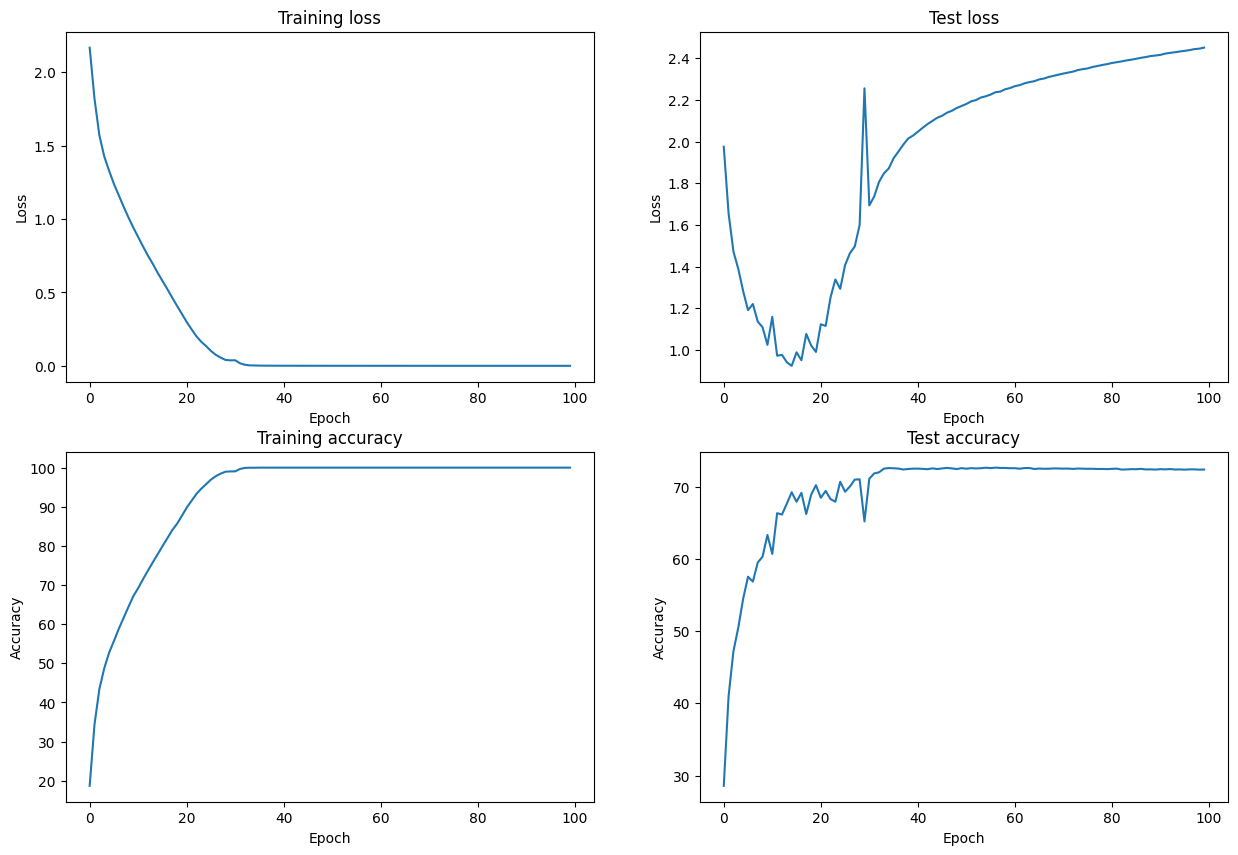

In [12]:
import matplotlib.pyplot as plt

# plot the training and validation loss
fig, ax = plt.subplots(2, 2, figsize=(15,10))
ax = ax.flatten()  # Flatten the array of axes for easier indexing

ax[0].plot(first_plot.loss_train, label="train loss")
ax[1].plot(first_plot.loss_test, label="val loss")
ax[2].plot(first_plot.acc_train, label="train accuracy")
ax[3].plot(first_plot.acc_test, label="val accuracy")

ax[0].set_title("Training loss")
ax[1].set_title("Test loss")
ax[2].set_title("Training accuracy")
ax[3].set_title("Test accuracy")

ax[0].set_xlabel("Epoch")
ax[1].set_xlabel("Epoch")
ax[2].set_xlabel("Epoch")
ax[3].set_xlabel("Epoch")

ax[0].set_ylabel("Loss")
ax[1].set_ylabel("Loss")
ax[2].set_ylabel("Accuracy")
ax[3].set_ylabel("Accuracy")

plt.show()


### Effect of learning rate

In [35]:
lr_effect = {}
for learning_rate in [0.1, 1e-2, 1e-3, 1e-4,1e-7]:
    print("Learning rate = ", learning_rate)
    lr_effect[learning_rate] = main(128, learning_rate,epochs=15,cuda=True)
    print("#"*50)

Learning rate =  0.1
Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15
##################################################
Learning rate =  0.01
Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15
##################################################
Learning rate =  0.001
Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15
##################################################
Learning rate =  0.0001
Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15
##################################################
Learning rate =  1e-07
Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15
##################################################


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

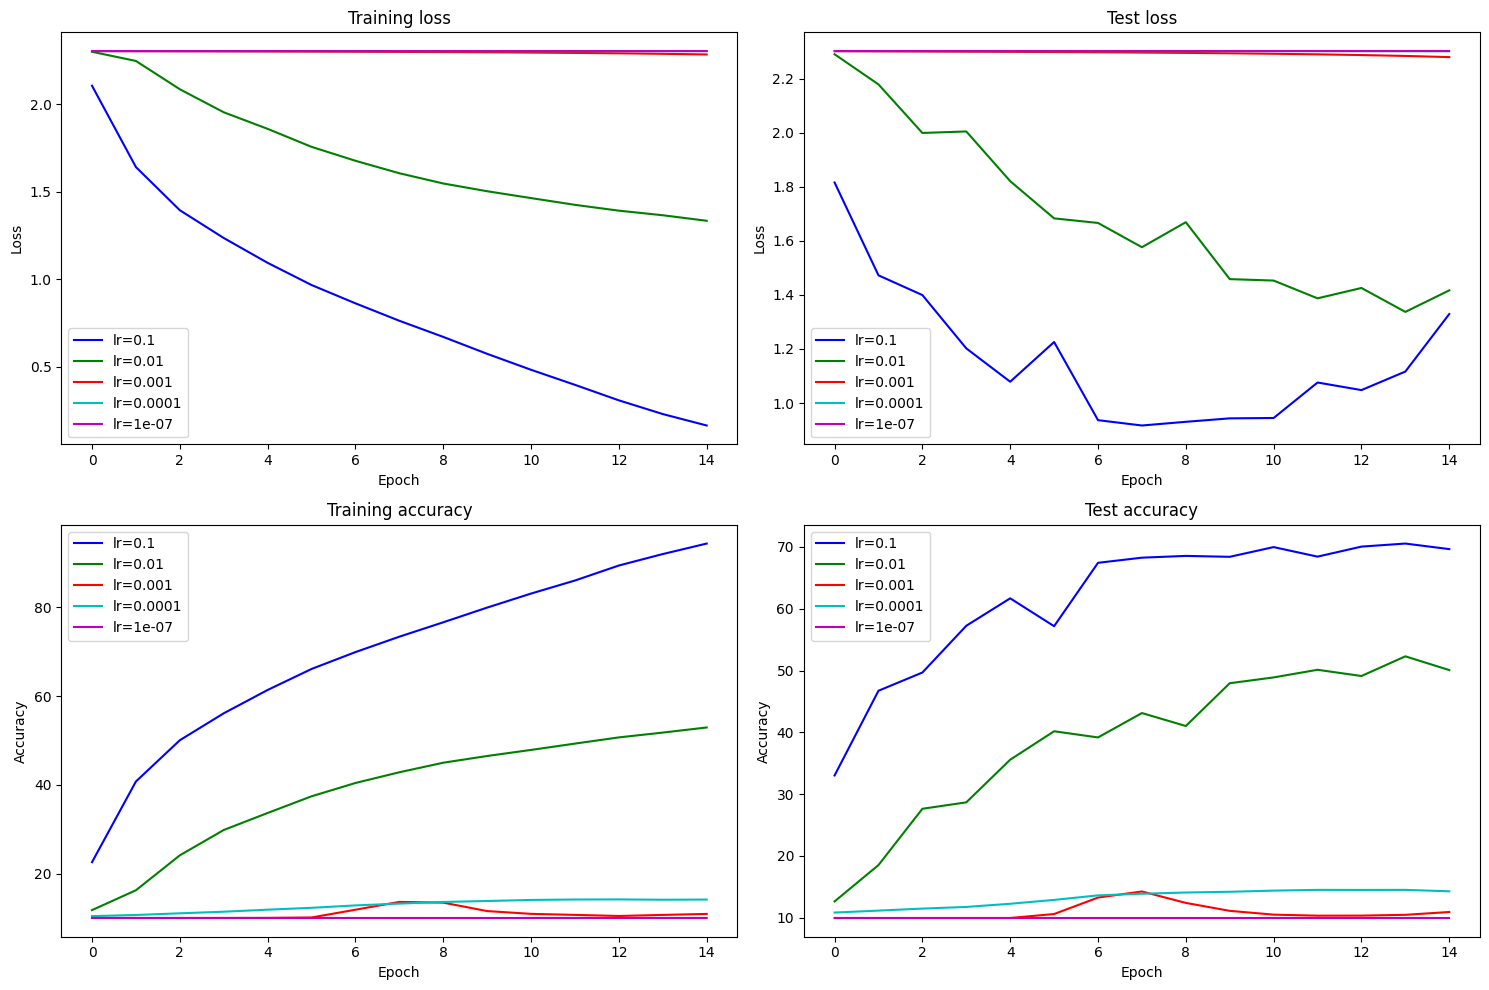

In [40]:
fig, ax = plt.subplots(2, 2, figsize=(15, 10))
ax = ax.flatten()

learning_rates = [0.1, 1e-2, 1e-3, 1e-4, 1e-7]
colors = ['b', 'g', 'r', 'c', 'm']  # Define a list of colors

for i, learning_rate in enumerate(learning_rates):
    ax[0].plot(lr_effect[learning_rate].loss_train, color=colors[i], label=f"lr={learning_rate}")
    ax[1].plot(lr_effect[learning_rate].loss_test, color=colors[i], label=f"lr={learning_rate}")
    ax[2].plot(lr_effect[learning_rate].acc_train, color=colors[i], label=f"lr={learning_rate}")
    ax[3].plot(lr_effect[learning_rate].acc_test, color=colors[i], label=f"lr={learning_rate}")

# Set titles
ax[0].set_title("Training loss")
ax[1].set_title("Test loss")
ax[2].set_title("Training accuracy")
ax[3].set_title("Test accuracy")

# Set labels
for i in range(4):
    ax[i].set_xlabel("Epoch")
    if i < 2:  # For the first row (loss)
        ax[i].set_ylabel("Loss")
    else:  # For the second row (accuracy)
        ax[i].set_ylabel("Accuracy")

# Add a legend
for i in range(4):
    ax[i].legend()

plt.tight_layout()
plt.show()


### Effect of batch_size

In [4]:
batch_effect ={}
for batch_size in [16,32, 64, 128, 256, 512]:
    print("Batch size = ", batch_size)
    batch_effect[batch_size] = main(batch_size, 0.1,epochs=15,cuda=True)
    print("#"*50)

Batch size =  16
Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15
##################################################
Batch size =  32
Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15
##################################################
Batch size =  64
Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15
##################################################
Batch size =  128
Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15
##################################################
Batch size =  256
Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15
##################################################
Batch size =  512
Epoch 1
Ep

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

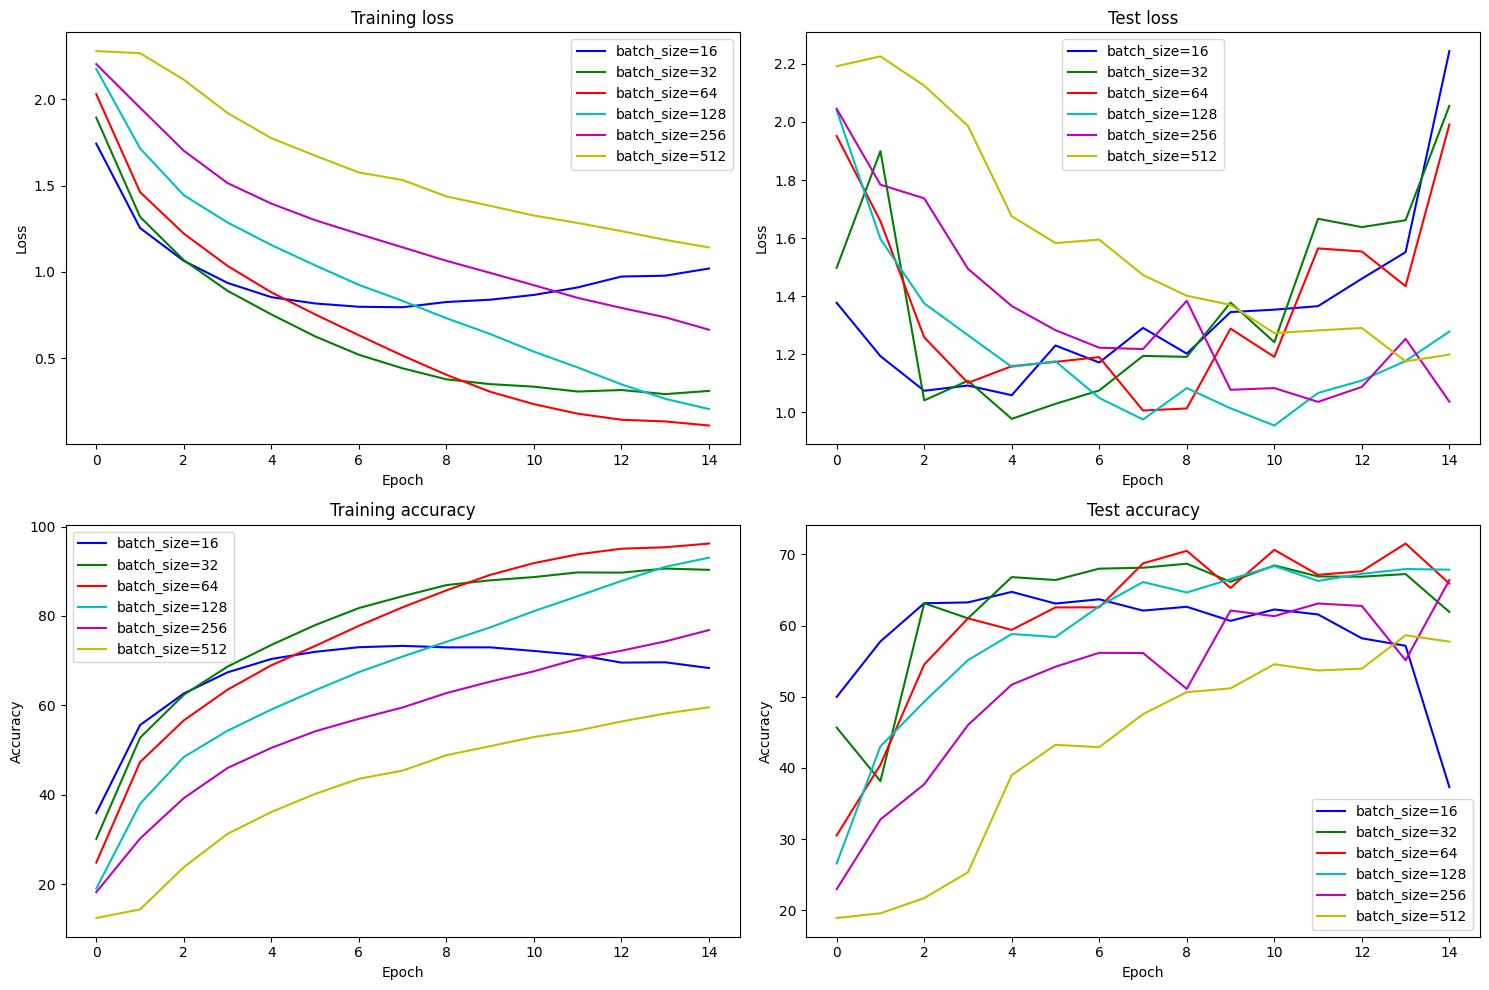

In [6]:
fig, ax = plt.subplots(2, 2, figsize=(15, 10))
ax = ax.flatten()

batch_sizes = [16,32, 64, 128, 256, 512]
colors = ['b', 'g', 'r', 'c', 'm','y']  # Define a list of colors

for i, batch_size in enumerate(batch_sizes):
    ax[0].plot(batch_effect[batch_size].loss_train, color=colors[i], label=f"batch_size={batch_size}")
    ax[1].plot(batch_effect[batch_size].loss_test, color=colors[i], label=f"batch_size={batch_size}")
    ax[2].plot(batch_effect[batch_size].acc_train, color=colors[i], label=f"batch_size={batch_size}")
    ax[3].plot(batch_effect[batch_size].acc_test, color=colors[i], label=f"batch_size={batch_size}")

# Set titles
ax[0].set_title("Training loss")
ax[1].set_title("Test loss")
ax[2].set_title("Training accuracy")
ax[3].set_title("Test accuracy")

# Set labels
for i in range(4):
    ax[i].set_xlabel("Epoch")
    if i < 2:  # For the first row (loss)
        ax[i].set_ylabel("Loss")
    else:  # For the second row (accuracy)
        ax[i].set_ylabel("Accuracy")

# Add a legend
for i in range(4):
    ax[i].legend()

plt.tight_layout()
plt.show()


# PART 3 : Results improvements

### 3.1 Standardization of examples

In [4]:
class ConvNet(nn.Module):
    """
    This class defines the structure of the neural network
    """

    def __init__(self):
        super(ConvNet, self).__init__()
        # We first define the convolution and pooling layers as a features extractor
        self.features = nn.Sequential(
            nn.Conv2d(3,32,(5,5),stride=1,padding=2),
            nn.ReLU(),
            nn.MaxPool2d((2,2),stride=2,padding=0),

            nn.Conv2d(32,64,(5,5),stride=1,padding=2),
            nn.ReLU(),
            nn.MaxPool2d((2,2),stride=2,padding=0),
            
            nn.Conv2d(64,64,(5,5),stride=1,padding=2),
            nn.ReLU(),
            nn.MaxPool2d((2,2),stride=2,padding=0)
        )
        # We then define fully connected layers as a classifier
        self.classifier = nn.Sequential(
            nn.Linear(1024, 1000),
            nn.ReLU(),
            nn.Linear(1000, 10),
            # Reminder: The softmax is included in the loss, do not put it here
        )

    # Method called when we apply the network to an input batch
    def forward(self, input):
        bsize = input.size(0) # batch size
        output = self.features(input) # output of the conv layers
        output = output.view(bsize, -1) # we flatten the 2D feature maps into one 1D vector for each input
        output = self.classifier(output) # we compute the output of the fc layers
        return output
    

def get_dataset(batch_size, cuda=False,transform="normalize"):
    """
    This function loads the dataset and performs transformations on each
    image (listed in `transform = ...`).
    """

    if transform == "normalize":
        train_dataset = datasets.CIFAR10(PATH, train=True, download=False,
            transform=transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize((0.4914, 0.482, 0.447), (0.202, 0.199, 0.201))
            ]))
        val_dataset = datasets.CIFAR10(PATH, train=False, download=False,
            transform=transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize((0.4914, 0.482, 0.447), (0.202, 0.199, 0.201))
            ]))
    
    elif transform == "augmentation":
        train_dataset = datasets.CIFAR10(PATH, train=True, download =False,
            transform=transforms.Compose([
                transforms.RandomCrop(28),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.Pad(2),
                transforms.ToTensor(),
                transforms.Normalize((0.4914, 0.482, 0.447), (0.202, 0.199, 0.201))

            ]))
        
        val_dataset = datasets.CIFAR10(PATH, train=False, download=False,
            transform=transforms.Compose([
                transforms.CenterCrop(28),
                transforms.Pad(2),
                transforms.ToTensor(),
                transforms.Normalize((0.4914, 0.482, 0.447), (0.202, 0.199, 0.201))
            ]))
        
    elif transform == "Color_augmentation":
        train_dataset = datasets.CIFAR10(PATH, train=True, download =False,
            transform=transforms.Compose([
                transforms.RandomCrop(28),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
                transforms.Pad(2),
                transforms.ToTensor(),
                transforms.Normalize((0.4914, 0.482, 0.447), (0.202, 0.199, 0.201))

            ]))
        
        val_dataset = datasets.CIFAR10(PATH, train=False, download=False,
            transform=transforms.Compose([
                transforms.CenterCrop(28),
                transforms.Pad(2),
                transforms.ToTensor(),
                transforms.Normalize((0.4914, 0.482, 0.447), (0.202, 0.199, 0.201))
            ]))
    elif transform == "Rotation":
        train_dataset = datasets.CIFAR10(PATH, train=True, download =False,
            transform=transforms.Compose([
                transforms.RandomCrop(28),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomRotation(15),  # Rotate images by 15 degrees
                transforms.Pad(2),
                transforms.ToTensor(),
                transforms.Normalize((0.4914, 0.482, 0.447), (0.202, 0.199, 0.201))

            ]))
        
        val_dataset = datasets.CIFAR10(PATH, train=False, download=False,
            transform=transforms.Compose([
                transforms.CenterCrop(28),
                transforms.Pad(2),
                transforms.ToTensor(),
                transforms.Normalize((0.4914, 0.482, 0.447), (0.202, 0.199, 0.201))
            ]))
    else:
        train_dataset = datasets.CIFAR10(PATH, train=True, download=False,
            transform=transforms.Compose([
                transforms.ToTensor()
            ]))
        val_dataset = datasets.CIFAR10(PATH, train=False, download=False,
            transform=transforms.Compose([
                transforms.ToTensor()
            ]))

    train_loader = torch.utils.data.DataLoader(train_dataset,
                        batch_size=batch_size, shuffle=True, pin_memory=cuda, num_workers=2)
    val_loader = torch.utils.data.DataLoader(val_dataset,
                        batch_size=batch_size, shuffle=False, pin_memory=cuda, num_workers=2)

    return train_loader, val_loader



def epoch(data, model, criterion, optimizer=None, cuda=False):
    """
    Make a pass (called epoch in English) on the data `data` with the
     model `model`. Evaluates `criterion` as loss.
     If `optimizer` is given, perform a training epoch using
     the given optimizer, otherwise, perform an evaluation epoch (no backward)
     of the model.
    """

    # indicates whether the model is in eval or train mode (some layers behave differently in train and eval)
    model.eval() if optimizer is None else model.train()

    # objects to store metric averages
    avg_loss = AverageMeter()
    avg_top1_acc = AverageMeter()
    avg_top5_acc = AverageMeter()
    avg_batch_time = AverageMeter()
    global loss_plot

    # we iterate on the batches
    tic = time.time()
    for i, (input, target) in enumerate(data):

        if cuda: # only with GPU, and not with CPU
            input = input.cuda()
            target = target.cuda()

        # forward
        output = model(input)
        loss = criterion(output, target)

        # backward if we are training
        if optimizer:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # compute metrics
        prec1, prec5 = accuracy(output, target, topk=(1, 5))
        batch_time = time.time() - tic
        tic = time.time()

        # update
        avg_loss.update(loss.item())
        avg_top1_acc.update(prec1.item())
        avg_top5_acc.update(prec5.item())
        avg_batch_time.update(batch_time)
        if optimizer:
            loss_plot.update(avg_loss.val)

    return avg_top1_acc, avg_top5_acc, avg_loss


def main(batch_size=128, lr=0.1, epochs=5, cuda=False,transform="normalize"):

    # ex :
    #   {"batch_size": 128, "epochs": 5, "lr": 0.1}

    # define model, loss, optim
    p = False
    model = ConvNet()
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr)

    if cuda: # only with GPU, and not with CPU
        cudnn.benchmark = True
        model = model.cuda()
        criterion = criterion.cuda()

    # Get the data
    train, test = get_dataset(batch_size, cuda,transform)

    # init plots
    plot = AccLossPlot()
    global loss_plot
    loss_plot = TrainLossPlot()

    # We iterate on the epochs 
    for i in range(epochs):
        # print("=================\n=== EPOCH "+str(i+1)+" =====\n=================\n")
        print("Epoch "+str(i+1))
        # Train phase
        top1_acc, avg_top5_acc, loss = epoch(train, model, criterion, optimizer, cuda)
        # Test phase
        top1_acc_test, top5_acc_test, loss_test = epoch(test, model, criterion, cuda=cuda)
        # plot
        plot.update(loss.avg, loss_test.avg, top1_acc.avg, top1_acc_test.avg,plot=p)

    return plot


In [5]:
normalized_plot= main(32, 0.01,epochs=100,cuda=True)

Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15
Epoch 16
Epoch 17
Epoch 18
Epoch 19
Epoch 20
Epoch 21
Epoch 22
Epoch 23
Epoch 24
Epoch 25
Epoch 26
Epoch 27
Epoch 28
Epoch 29
Epoch 30
Epoch 31
Epoch 32
Epoch 33
Epoch 34
Epoch 35
Epoch 36
Epoch 37
Epoch 38
Epoch 39
Epoch 40
Epoch 41
Epoch 42
Epoch 43
Epoch 44
Epoch 45
Epoch 46
Epoch 47
Epoch 48
Epoch 49
Epoch 50
Epoch 51
Epoch 52
Epoch 53
Epoch 54
Epoch 55
Epoch 56
Epoch 57
Epoch 58
Epoch 59
Epoch 60
Epoch 61
Epoch 62
Epoch 63
Epoch 64
Epoch 65
Epoch 66
Epoch 67
Epoch 68
Epoch 69
Epoch 70
Epoch 71
Epoch 72
Epoch 73
Epoch 74
Epoch 75
Epoch 76
Epoch 77
Epoch 78
Epoch 79
Epoch 80
Epoch 81
Epoch 82
Epoch 83
Epoch 84
Epoch 85
Epoch 86
Epoch 87
Epoch 88
Epoch 89
Epoch 90
Epoch 91
Epoch 92
Epoch 93
Epoch 94
Epoch 95
Epoch 96
Epoch 97
Epoch 98
Epoch 99
Epoch 100


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

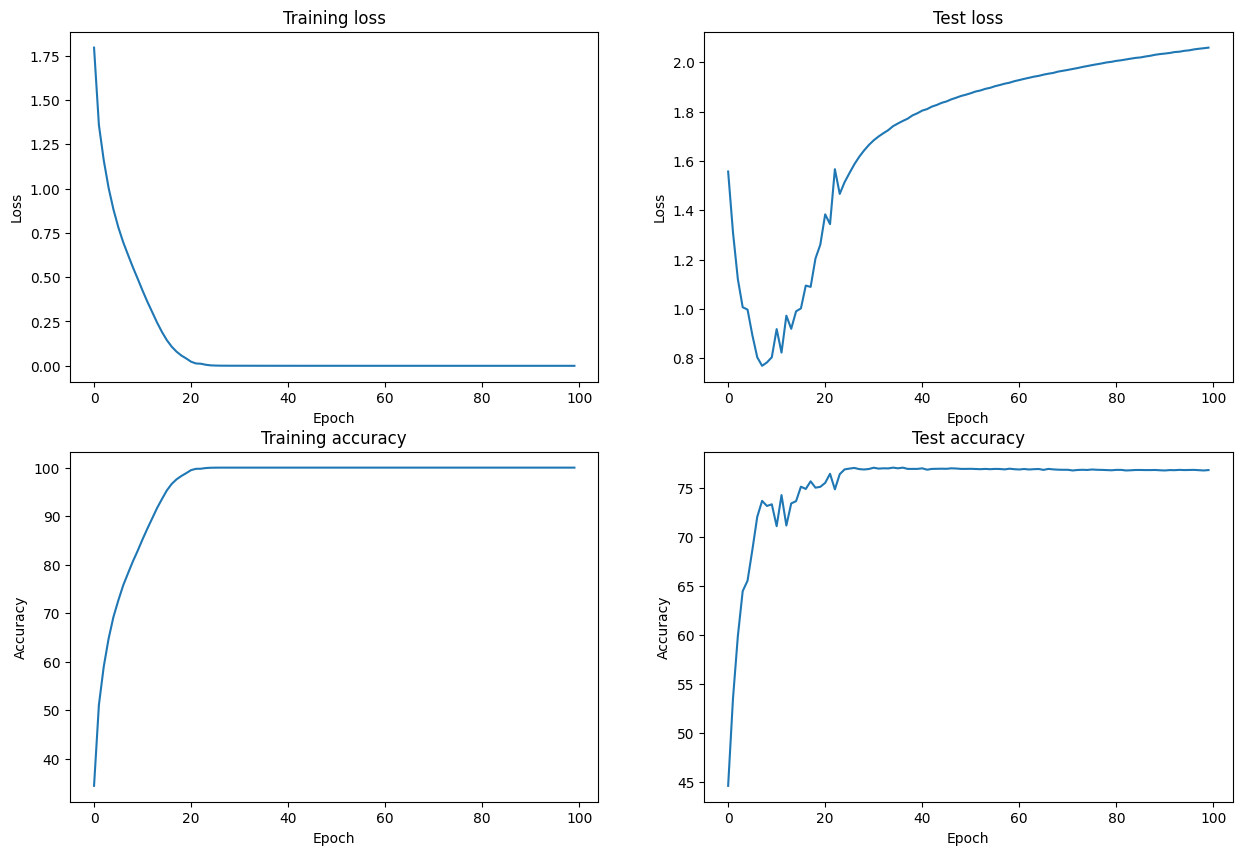

In [6]:
import matplotlib.pyplot as plt

# plot the training and validation loss
fig, ax = plt.subplots(2, 2, figsize=(15,10))
ax = ax.flatten()  # Flatten the array of axes for easier indexing

ax[0].plot(normalized_plot.loss_train, label="train loss")
ax[1].plot(normalized_plot.loss_test, label="val loss")
ax[2].plot(normalized_plot.acc_train, label="train accuracy")
ax[3].plot(normalized_plot.acc_test, label="val accuracy")

ax[0].set_title("Training loss")
ax[1].set_title("Test loss")
ax[2].set_title("Training accuracy")
ax[3].set_title("Test accuracy")

ax[0].set_xlabel("Epoch")
ax[1].set_xlabel("Epoch")
ax[2].set_xlabel("Epoch")
ax[3].set_xlabel("Epoch")

ax[0].set_ylabel("Loss")
ax[1].set_ylabel("Loss")
ax[2].set_ylabel("Accuracy")
ax[3].set_ylabel("Accuracy")

plt.show()


In [8]:
normalized_plot_1= main(32, 0.1,epochs=15,cuda=True)


Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

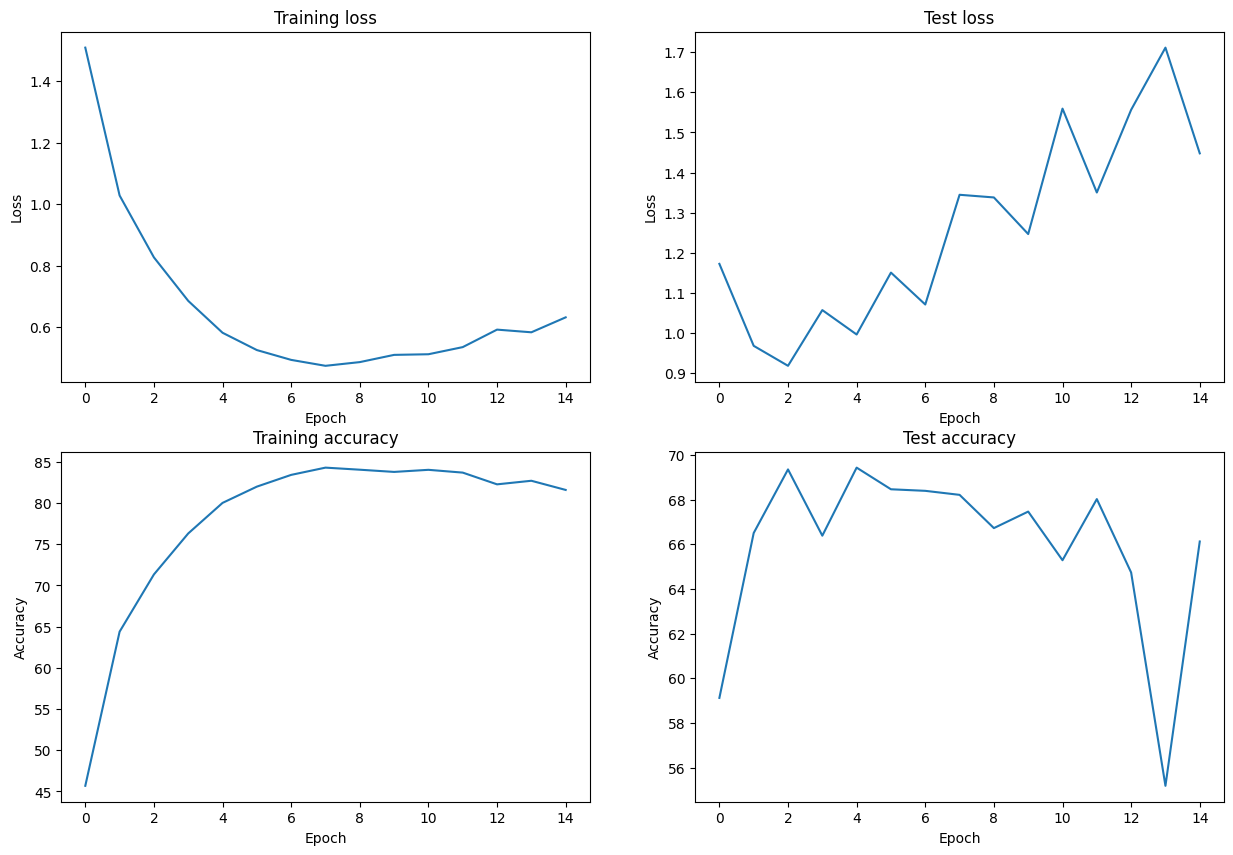

In [9]:
import matplotlib.pyplot as plt

# plot the training and validation loss
fig, ax = plt.subplots(2, 2, figsize=(15,10))
ax = ax.flatten()  # Flatten the array of axes for easier indexing

ax[0].plot(normalized_plot_1.loss_train, label="train loss")
ax[1].plot(normalized_plot_1.loss_test, label="val loss")
ax[2].plot(normalized_plot_1.acc_train, label="train accuracy")
ax[3].plot(normalized_plot_1.acc_test, label="val accuracy")

ax[0].set_title("Training loss")
ax[1].set_title("Test loss")
ax[2].set_title("Training accuracy")
ax[3].set_title("Test accuracy")

ax[0].set_xlabel("Epoch")
ax[1].set_xlabel("Epoch")
ax[2].set_xlabel("Epoch")
ax[3].set_xlabel("Epoch")

ax[0].set_ylabel("Loss")
ax[1].set_ylabel("Loss")
ax[2].set_ylabel("Accuracy")
ax[3].set_ylabel("Accuracy")

plt.show()


In [10]:
normalized_plot_2= main(64, 0.1,epochs=15,cuda=True)

Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

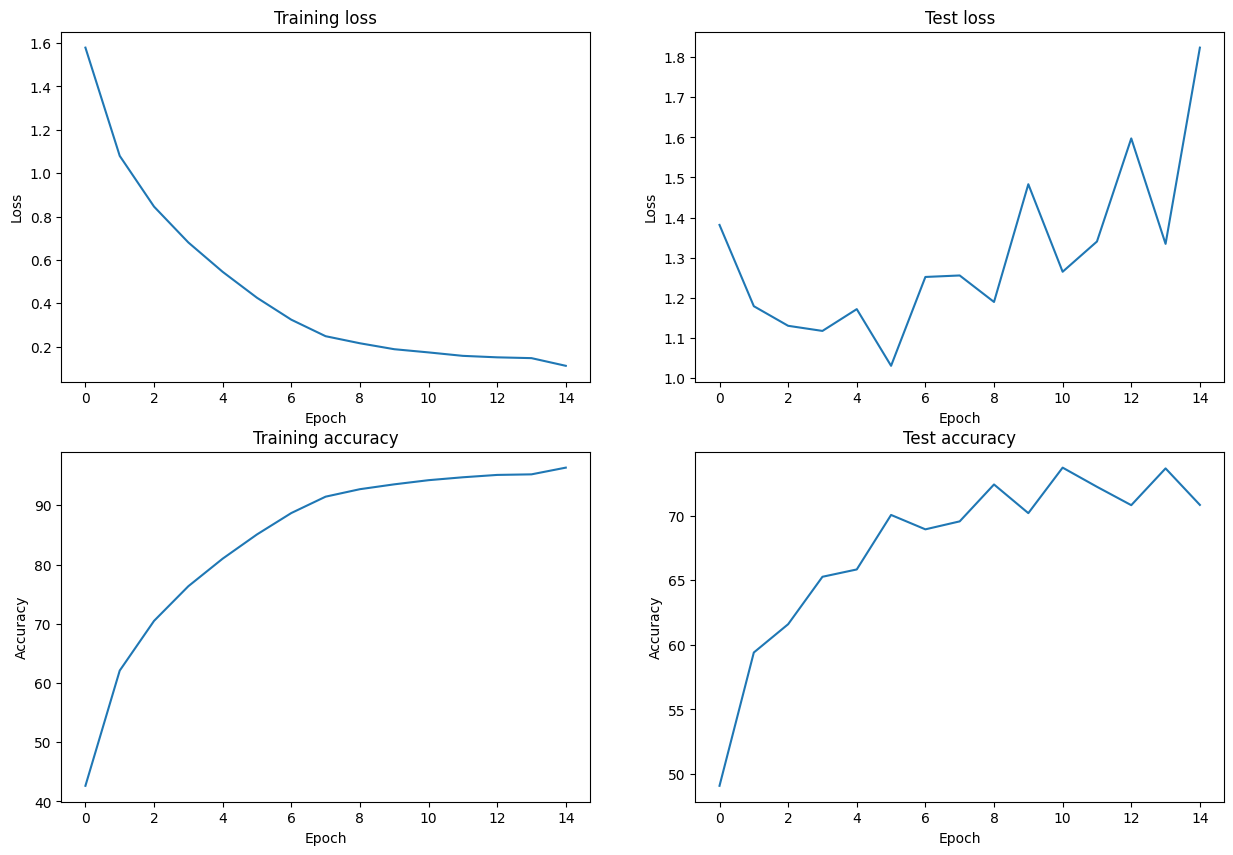

In [11]:
# plot the training and validation loss
fig, ax = plt.subplots(2, 2, figsize=(15,10))
ax = ax.flatten()  # Flatten the array of axes for easier indexing

ax[0].plot(normalized_plot_2.loss_train, label="train loss")
ax[1].plot(normalized_plot_2.loss_test, label="val loss")
ax[2].plot(normalized_plot_2.acc_train, label="train accuracy")
ax[3].plot(normalized_plot_2.acc_test, label="val accuracy")

ax[0].set_title("Training loss")
ax[1].set_title("Test loss")
ax[2].set_title("Training accuracy")
ax[3].set_title("Test accuracy")

ax[0].set_xlabel("Epoch")
ax[1].set_xlabel("Epoch")
ax[2].set_xlabel("Epoch")
ax[3].set_xlabel("Epoch")

ax[0].set_ylabel("Loss")
ax[1].set_ylabel("Loss")
ax[2].set_ylabel("Accuracy")
ax[3].set_ylabel("Accuracy")

plt.show()

In [15]:
normalized_plot_3= main(64, 0.01,epochs=15,cuda=True)

Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

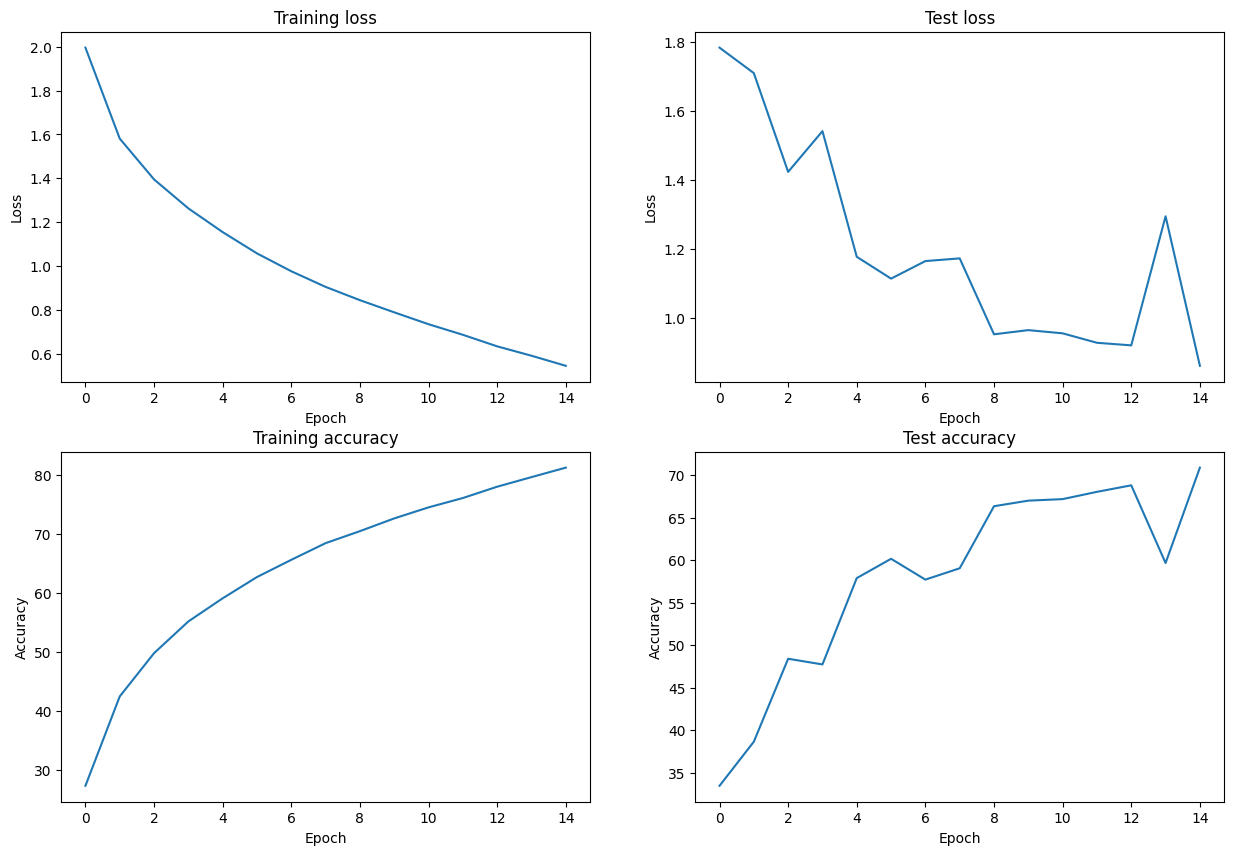

In [16]:
# plot the training and validation loss
fig, ax = plt.subplots(2, 2, figsize=(15,10))
ax = ax.flatten()  # Flatten the array of axes for easier indexing

ax[0].plot(normalized_plot_3.loss_train, label="train loss")
ax[1].plot(normalized_plot_3.loss_test, label="val loss")
ax[2].plot(normalized_plot_3.acc_train, label="train accuracy")
ax[3].plot(normalized_plot_3.acc_test, label="val accuracy")

ax[0].set_title("Training loss")
ax[1].set_title("Test loss")
ax[2].set_title("Training accuracy")
ax[3].set_title("Test accuracy")

ax[0].set_xlabel("Epoch")
ax[1].set_xlabel("Epoch")
ax[2].set_xlabel("Epoch")
ax[3].set_xlabel("Epoch")

ax[0].set_ylabel("Loss")
ax[1].set_ylabel("Loss")
ax[2].set_ylabel("Accuracy")
ax[3].set_ylabel("Accuracy")

plt.show()

### 3.2 Increase in the number of training examples by data increase

In [5]:
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        # We first define the convolution and pooling layers as a features extractor
        self.features = nn.Sequential(
            nn.Conv2d(3,32,(5,5),stride=1,padding=2),
            nn.ReLU(),
            nn.MaxPool2d((2,2),stride=2,padding=0),

            nn.Conv2d(32,64,(5,5),stride=1,padding=2),
            nn.ReLU(),
            nn.MaxPool2d((2,2),stride=2,padding=0),
            
            nn.Conv2d(64,64,(5,5),stride=1,padding=2),
            nn.ReLU(),
            nn.MaxPool2d((2,2),stride=2,padding=0, ceil_mode=True) 
        )
        # We then define fully connected layers as a classifier
        self.classifier = nn.Sequential(
            nn.Linear(1024, 1000),
            nn.ReLU(),
            nn.Linear(1000, 10),
            # Reminder: The softmax is included in the loss, do not put it here
        )

    # Method called when we apply the network to an input batch
    def forward(self, input):
        bsize = input.size(0) # batch size
        output = self.features(input) # output of the conv layers
        output = output.view(bsize, -1) # we flatten the 2D feature maps into one 1D vector for each input
        output = self.classifier(output) # we compute the output of the fc layers
        return output

In [6]:
augmentation_plot = main(32, 0.01,epochs=100,cuda=True,transform = "augmentation") 

Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15
Epoch 16
Epoch 17
Epoch 18
Epoch 19
Epoch 20
Epoch 21
Epoch 22
Epoch 23
Epoch 24
Epoch 25
Epoch 26
Epoch 27
Epoch 28
Epoch 29
Epoch 30
Epoch 31
Epoch 32
Epoch 33
Epoch 34
Epoch 35
Epoch 36
Epoch 37
Epoch 38
Epoch 39
Epoch 40
Epoch 41
Epoch 42
Epoch 43
Epoch 44
Epoch 45
Epoch 46
Epoch 47
Epoch 48
Epoch 49
Epoch 50
Epoch 51
Epoch 52
Epoch 53
Epoch 54
Epoch 55
Epoch 56
Epoch 57
Epoch 58
Epoch 59
Epoch 60
Epoch 61
Epoch 62
Epoch 63
Epoch 64
Epoch 65
Epoch 66
Epoch 67
Epoch 68
Epoch 69
Epoch 70
Epoch 71
Epoch 72
Epoch 73
Epoch 74
Epoch 75
Epoch 76
Epoch 77
Epoch 78
Epoch 79
Epoch 80
Epoch 81
Epoch 82
Epoch 83
Epoch 84
Epoch 85
Epoch 86
Epoch 87
Epoch 88
Epoch 89
Epoch 90
Epoch 91
Epoch 92
Epoch 93
Epoch 94
Epoch 95
Epoch 96
Epoch 97
Epoch 98
Epoch 99
Epoch 100


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

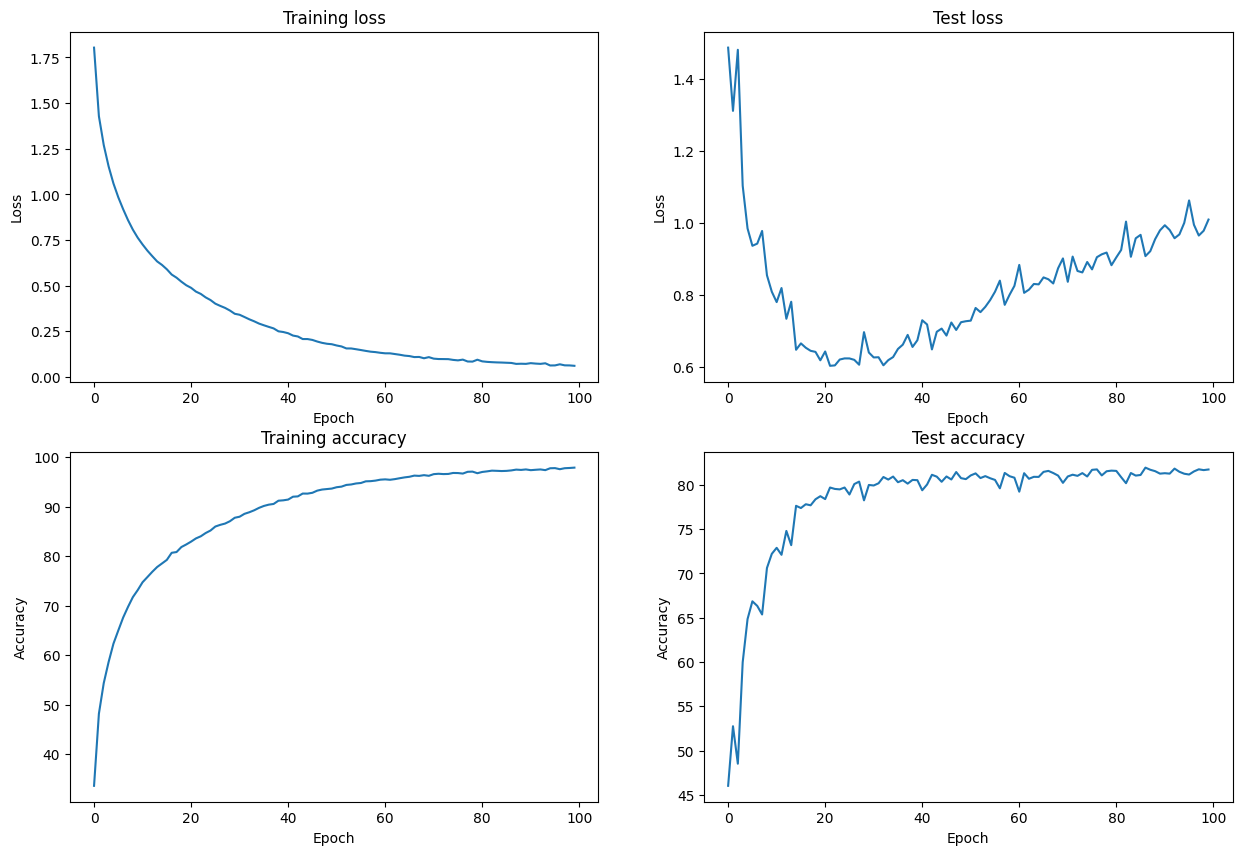

In [7]:
fig, ax = plt.subplots(2, 2, figsize=(15,10))
ax = ax.flatten()  # Flatten the array of axes for easier indexing

ax[0].plot(augmentation_plot.loss_train, label="train loss")
ax[1].plot(augmentation_plot.loss_test, label="val loss")
ax[2].plot(augmentation_plot.acc_train, label="train accuracy")
ax[3].plot(augmentation_plot.acc_test, label="val accuracy")

ax[0].set_title("Training loss")
ax[1].set_title("Test loss")
ax[2].set_title("Training accuracy")
ax[3].set_title("Test accuracy")

ax[0].set_xlabel("Epoch")
ax[1].set_xlabel("Epoch")
ax[2].set_xlabel("Epoch")
ax[3].set_xlabel("Epoch")

ax[0].set_ylabel("Loss")
ax[1].set_ylabel("Loss")
ax[2].set_ylabel("Accuracy")
ax[3].set_ylabel("Accuracy")

plt.show()

**Bonus** : Other data augmentation methods: <br> <br>
Random rotation : transforms.RandomRotation(15),<br>
Color Jitter: transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),<br>

Random Erasing: Randomly setting a portion of the image to zero. **(not implemented)**<br>
Gaussian Noise: Adding noise to the images. **(not implemented)**<br>
Perspective Transform: Altering the perspective of images. **(not implemented)**<br>
Cutout: Masking random sections of the image. **(not implemented)**<br>

In [21]:
color_augmentation_plot = main(32, 0.01,epochs=15,cuda=True,transform = "Color_augmentation")

Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

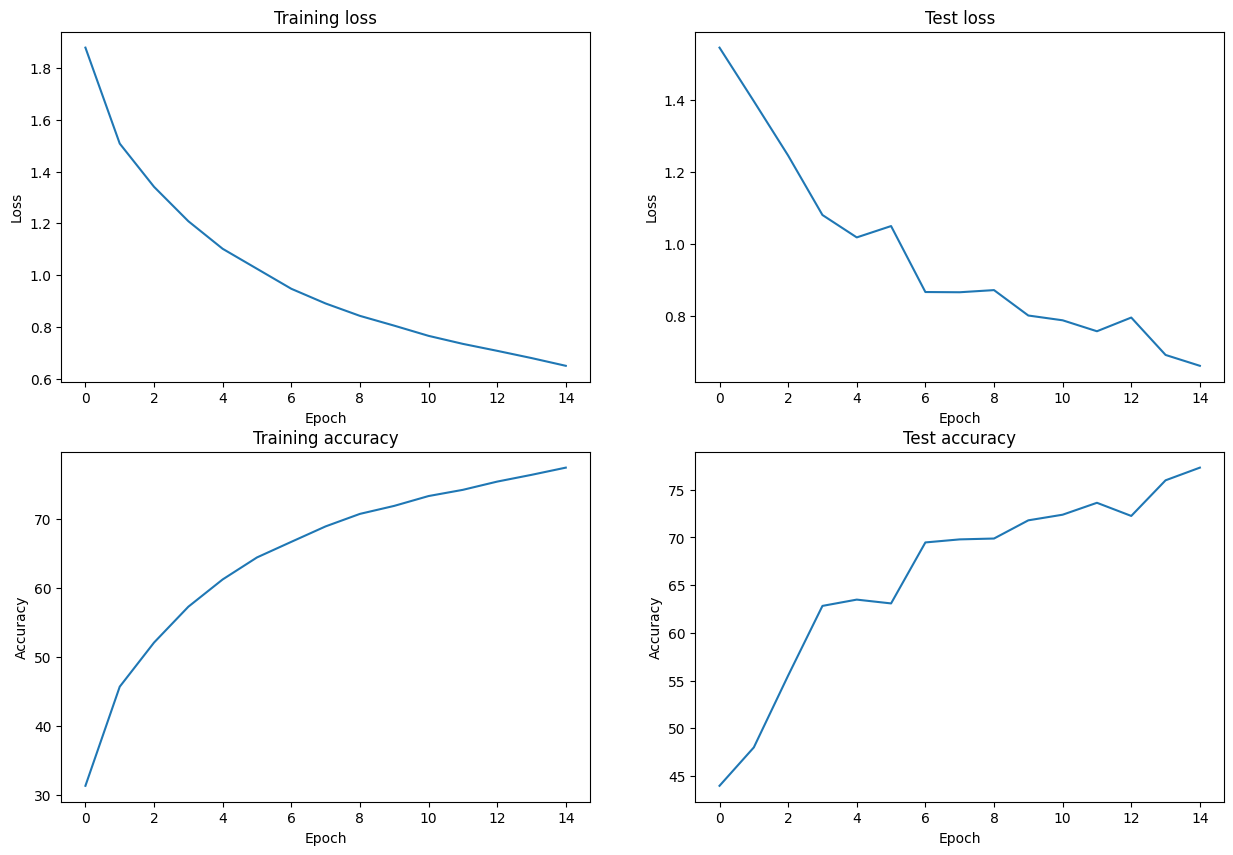

In [22]:
fig, ax = plt.subplots(2, 2, figsize=(15,10))
ax = ax.flatten()  # Flatten the array of axes for easier indexing

ax[0].plot(color_augmentation_plot.loss_train, label="train loss")
ax[1].plot(color_augmentation_plot.loss_test, label="val loss")
ax[2].plot(color_augmentation_plot.acc_train, label="train accuracy")
ax[3].plot(color_augmentation_plot.acc_test, label="val accuracy")

ax[0].set_title("Training loss")
ax[1].set_title("Test loss")
ax[2].set_title("Training accuracy")
ax[3].set_title("Test accuracy")

ax[0].set_xlabel("Epoch")
ax[1].set_xlabel("Epoch")
ax[2].set_xlabel("Epoch")
ax[3].set_xlabel("Epoch")

ax[0].set_ylabel("Loss")
ax[1].set_ylabel("Loss")
ax[2].set_ylabel("Accuracy")
ax[3].set_ylabel("Accuracy")

plt.show()

In [23]:
rotation_augmentation_plot = main(32, 0.01,epochs=15,cuda=True,transform = "Rotation")

Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

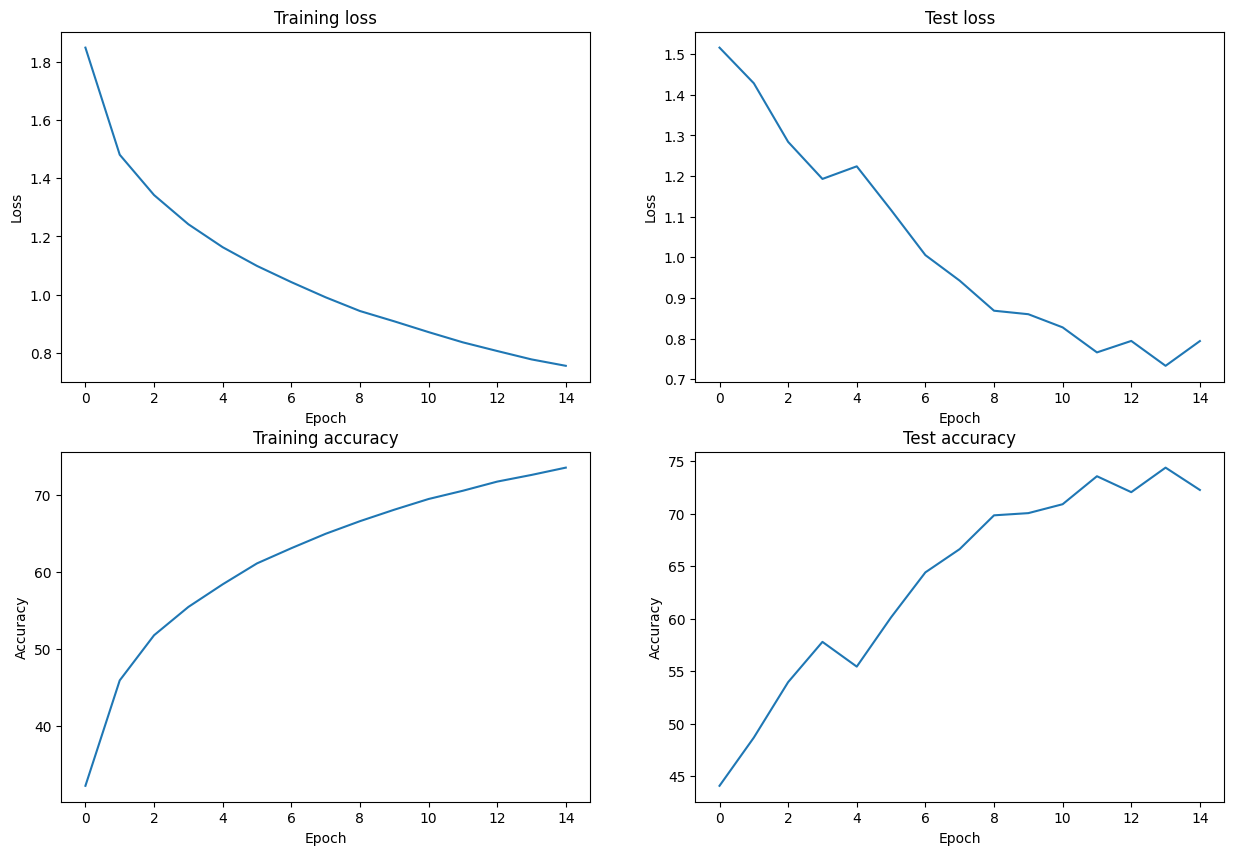

In [24]:
fig, ax = plt.subplots(2, 2, figsize=(15,10))
ax = ax.flatten()  # Flatten the array of axes for easier indexing

ax[0].plot(rotation_augmentation_plot.loss_train, label="train loss")
ax[1].plot(rotation_augmentation_plot.loss_test, label="val loss")
ax[2].plot(rotation_augmentation_plot.acc_train, label="train accuracy")
ax[3].plot(rotation_augmentation_plot.acc_test, label="val accuracy")

ax[0].set_title("Training loss")
ax[1].set_title("Test loss")
ax[2].set_title("Training accuracy")
ax[3].set_title("Test accuracy")

ax[0].set_xlabel("Epoch")
ax[1].set_xlabel("Epoch")
ax[2].set_xlabel("Epoch")
ax[3].set_xlabel("Epoch")

ax[0].set_ylabel("Loss")
ax[1].set_ylabel("Loss")
ax[2].set_ylabel("Accuracy")
ax[3].set_ylabel("Accuracy")

plt.show()

## 3.3 Variants on the optimization algorithm

In [6]:
import torch.optim.lr_scheduler

def main_with_schd(batch_size=128, lr=0.1, epochs=5, cuda=False,transform="normalize"):
    p = False
    model = ConvNet()
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr)

    if cuda: # only with GPU, and not with CPU
        cudnn.benchmark = True
        model = model.cuda()
        criterion = criterion.cuda()

    # Get the data
    train, test = get_dataset(batch_size, cuda,transform)

    # init plots
    plot = AccLossPlot()
    global loss_plot
    loss_plot = TrainLossPlot()

    # scheduler :
    lr_sched = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95) # lr will decrease by 5% after every epoch.


    # We iterate on the epochs 
    for i in range(epochs):
        # print("=================\n=== EPOCH "+str(i+1)+" =====\n=================\n")
        print("Epoch "+str(i+1))
        # Train phase
        top1_acc, avg_top5_acc, loss = epoch(train, model, criterion, optimizer, cuda)
        # Test phase
        top1_acc_test, top5_acc_test, loss_test = epoch(test, model, criterion, cuda=cuda)
        
        # step the scheduler after one epoch
        lr_sched.step()

        # plot
        plot.update(loss.avg, loss_test.avg, top1_acc.avg, top1_acc_test.avg,plot=p)

    return plot


In [7]:
lr_schedul_plot = main_with_schd(32, 0.01,epochs=100,cuda=True,transform = "normalize")

Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15
Epoch 16
Epoch 17
Epoch 18
Epoch 19
Epoch 20
Epoch 21
Epoch 22
Epoch 23
Epoch 24
Epoch 25
Epoch 26
Epoch 27
Epoch 28
Epoch 29
Epoch 30
Epoch 31
Epoch 32
Epoch 33
Epoch 34
Epoch 35
Epoch 36
Epoch 37
Epoch 38
Epoch 39
Epoch 40
Epoch 41
Epoch 42
Epoch 43
Epoch 44
Epoch 45
Epoch 46
Epoch 47
Epoch 48
Epoch 49
Epoch 50
Epoch 51
Epoch 52
Epoch 53
Epoch 54
Epoch 55
Epoch 56
Epoch 57
Epoch 58
Epoch 59
Epoch 60
Epoch 61
Epoch 62
Epoch 63
Epoch 64
Epoch 65
Epoch 66
Epoch 67
Epoch 68
Epoch 69
Epoch 70
Epoch 71
Epoch 72
Epoch 73
Epoch 74
Epoch 75
Epoch 76
Epoch 77
Epoch 78
Epoch 79
Epoch 80
Epoch 81
Epoch 82
Epoch 83
Epoch 84
Epoch 85
Epoch 86
Epoch 87
Epoch 88
Epoch 89
Epoch 90
Epoch 91
Epoch 92
Epoch 93
Epoch 94
Epoch 95
Epoch 96
Epoch 97
Epoch 98
Epoch 99
Epoch 100


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

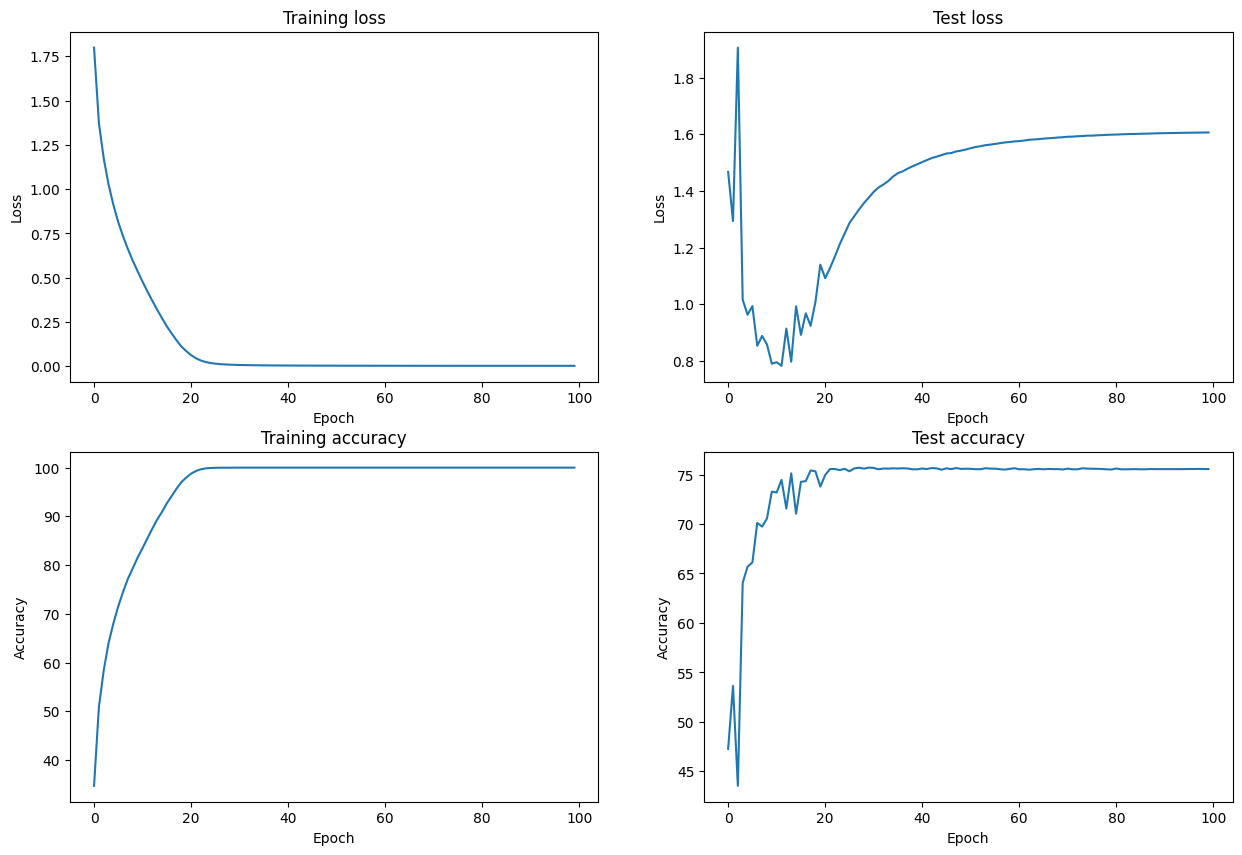

In [8]:
fig, ax = plt.subplots(2, 2, figsize=(15,10))
ax = ax.flatten()  # Flatten the array of axes for easier indexing

ax[0].plot(lr_schedul_plot.loss_train, label="train loss")
ax[1].plot(lr_schedul_plot.loss_test, label="val loss")
ax[2].plot(lr_schedul_plot.acc_train, label="train accuracy")
ax[3].plot(lr_schedul_plot.acc_test, label="val accuracy")

ax[0].set_title("Training loss")
ax[1].set_title("Test loss")
ax[2].set_title("Training accuracy")
ax[3].set_title("Test accuracy")

ax[0].set_xlabel("Epoch")
ax[1].set_xlabel("Epoch")
ax[2].set_xlabel("Epoch")
ax[3].set_xlabel("Epoch")

ax[0].set_ylabel("Loss")
ax[1].set_ylabel("Loss")
ax[2].set_ylabel("Accuracy")
ax[3].set_ylabel("Accuracy")

plt.show()

In [19]:
lr_schedul_plot_2 = main_with_schd(64, 0.1,epochs=15,cuda=True,transform = "normalize")

Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

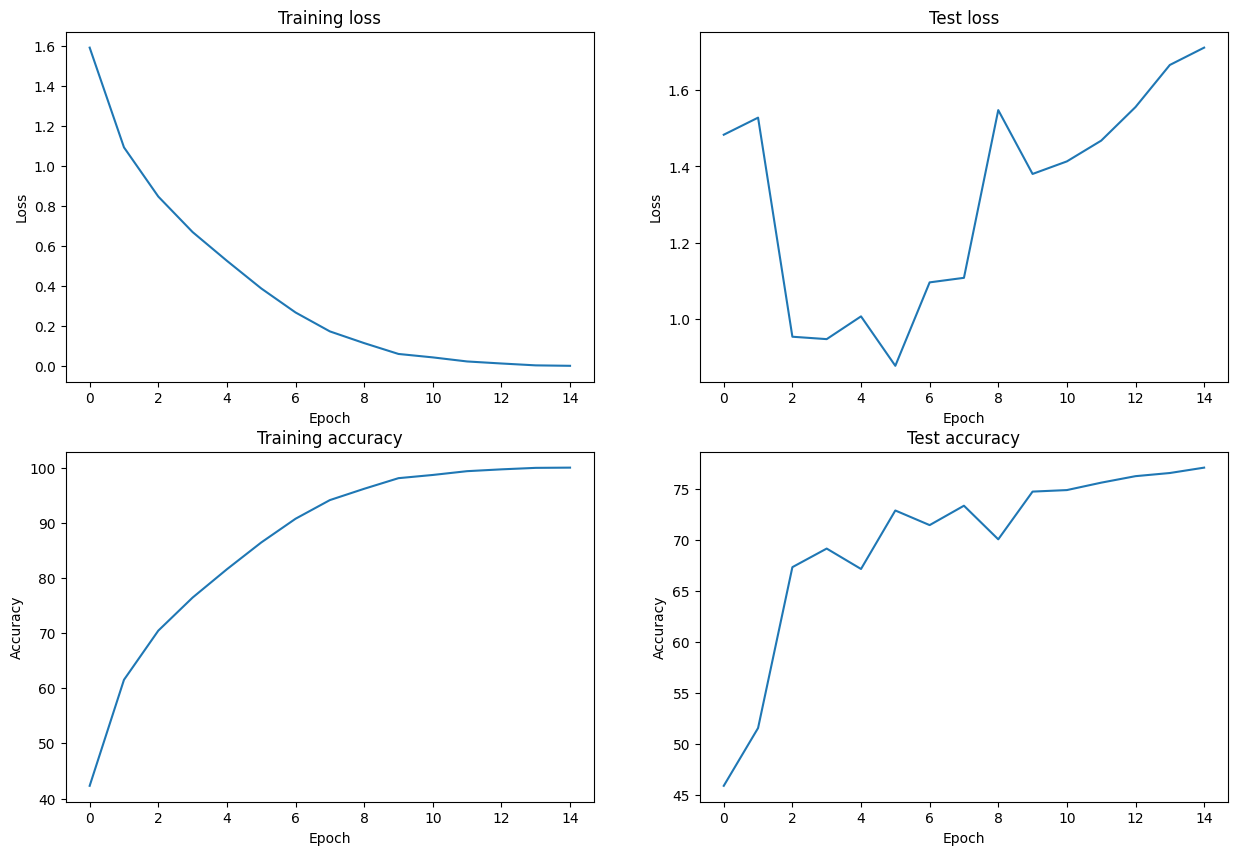

In [20]:
fig, ax = plt.subplots(2, 2, figsize=(15,10))
ax = ax.flatten()  # Flatten the array of axes for easier indexing

ax[0].plot(lr_schedul_plot_2.loss_train, label="train loss")
ax[1].plot(lr_schedul_plot_2.loss_test, label="val loss")
ax[2].plot(lr_schedul_plot_2.acc_train, label="train accuracy")
ax[3].plot(lr_schedul_plot_2.acc_test, label="val accuracy")

ax[0].set_title("Training loss")
ax[1].set_title("Test loss")
ax[2].set_title("Training accuracy")
ax[3].set_title("Test accuracy")

ax[0].set_xlabel("Epoch")
ax[1].set_xlabel("Epoch")
ax[2].set_xlabel("Epoch")
ax[3].set_xlabel("Epoch")

ax[0].set_ylabel("Loss")
ax[1].set_ylabel("Loss")
ax[2].set_ylabel("Accuracy")
ax[3].set_ylabel("Accuracy")

plt.show()

**Bonus**: using Adam optimizer 
<br> with the StepLR lr scheduler

In [10]:
def main_with_adam_StepLR(batch_size=128, lr=0.1, epochs=5, cuda=False,transform="normalize"):
    p = False
    model = ConvNet()
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr)

    if cuda: # only with GPU, and not with CPU
        cudnn.benchmark = True
        model = model.cuda()
        criterion = criterion.cuda()

    # Get the data
    train, test = get_dataset(batch_size, cuda,transform)

    # init plots
    plot = AccLossPlot()
    global loss_plot
    loss_plot = TrainLossPlot()

    # scheduler :
    lr_sched = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1) # lr will decrease by 50% every 5 epochs.


    # We iterate on the epochs 
    for i in range(epochs):
        # print("=================\n=== EPOCH "+str(i+1)+" =====\n=================\n")
        print("Epoch "+str(i+1))
        # Train phase
        top1_acc, avg_top5_acc, loss = epoch(train, model, criterion, optimizer, cuda)
        # Test phase
        top1_acc_test, top5_acc_test, loss_test = epoch(test, model, criterion, cuda=cuda)
        
        # step the scheduler after one epoch
        lr_sched.step()

        # plot
        plot.update(loss.avg, loss_test.avg, top1_acc.avg, top1_acc_test.avg,plot=p)

    return plot


In [11]:
adam_stepLr_plot = main_with_adam_StepLR(32, 0.1,epochs=100,cuda=True,transform = "normalize")

Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15
Epoch 16
Epoch 17
Epoch 18
Epoch 19
Epoch 20
Epoch 21
Epoch 22
Epoch 23
Epoch 24
Epoch 25
Epoch 26
Epoch 27
Epoch 28
Epoch 29
Epoch 30
Epoch 31
Epoch 32
Epoch 33
Epoch 34
Epoch 35
Epoch 36
Epoch 37
Epoch 38
Epoch 39
Epoch 40
Epoch 41
Epoch 42
Epoch 43
Epoch 44
Epoch 45
Epoch 46
Epoch 47
Epoch 48
Epoch 49
Epoch 50
Epoch 51
Epoch 52
Epoch 53
Epoch 54
Epoch 55
Epoch 56
Epoch 57
Epoch 58
Epoch 59
Epoch 60
Epoch 61
Epoch 62
Epoch 63
Epoch 64
Epoch 65
Epoch 66
Epoch 67
Epoch 68
Epoch 69
Epoch 70
Epoch 71
Epoch 72
Epoch 73
Epoch 74
Epoch 75
Epoch 76
Epoch 77
Epoch 78
Epoch 79
Epoch 80
Epoch 81
Epoch 82
Epoch 83
Epoch 84
Epoch 85
Epoch 86
Epoch 87
Epoch 88
Epoch 89
Epoch 90
Epoch 91
Epoch 92
Epoch 93
Epoch 94
Epoch 95
Epoch 96
Epoch 97
Epoch 98
Epoch 99
Epoch 100


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

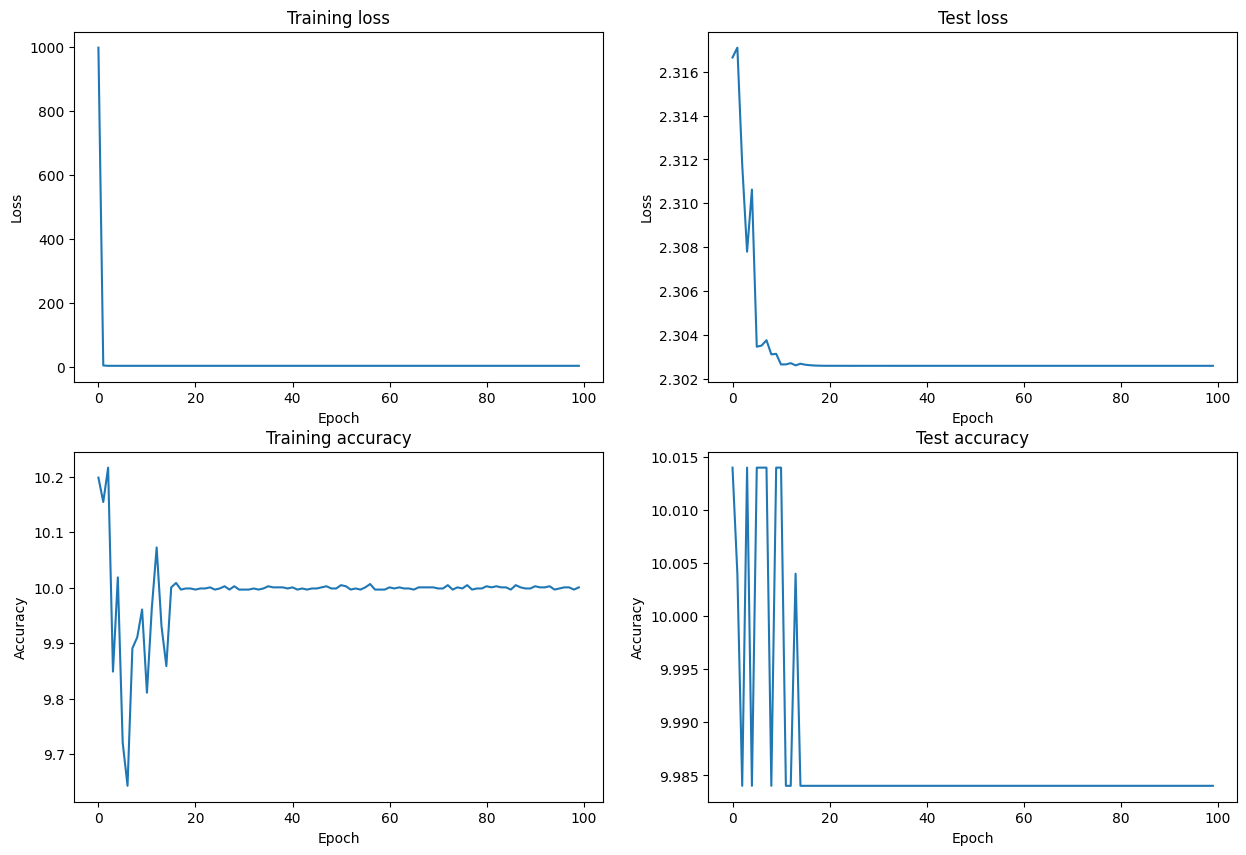

In [12]:
fig, ax = plt.subplots(2, 2, figsize=(15,10))
ax = ax.flatten()  # Flatten the array of axes for easier indexing

ax[0].plot(adam_stepLr_plot.loss_train, label="train loss")
ax[1].plot(adam_stepLr_plot.loss_test, label="val loss")
ax[2].plot(adam_stepLr_plot.acc_train, label="train accuracy")
ax[3].plot(adam_stepLr_plot.acc_test, label="val accuracy")

ax[0].set_title("Training loss")
ax[1].set_title("Test loss")
ax[2].set_title("Training accuracy")
ax[3].set_title("Test accuracy")

ax[0].set_xlabel("Epoch")
ax[1].set_xlabel("Epoch")
ax[2].set_xlabel("Epoch")
ax[3].set_xlabel("Epoch")

ax[0].set_ylabel("Loss")
ax[1].set_ylabel("Loss")
ax[2].set_ylabel("Accuracy")
ax[3].set_ylabel("Accuracy")

plt.show()

In [7]:
import torch
import torch.nn as nn
import torch.backends.cudnn as cudnn

def main_with_adam_PolynomialLR(batch_size=128, lr=0.1, epochs=5, cuda=False, transform="normalize"):
    p = False
    model = ConvNet()
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr)

    if cuda:  # only with GPU, and not with CPU
        cudnn.benchmark = True
        model = model.cuda()
        criterion = criterion.cuda()

    # Get the data
    train, test = get_dataset(batch_size, cuda, transform)

    # init plots
    plot = AccLossPlot()
    global loss_plot
    loss_plot = TrainLossPlot()

    # Calculate total iterations
    total_iters = epochs * len(train)  # Assuming `train` is a DataLoader

    # PolynomialLR scheduler: Here, `power` determines the decay rate
    lr_sched = torch.optim.lr_scheduler.PolynomialLR(optimizer, total_iters=total_iters, power=2.0)

    # We iterate on the epochs 
    for i in range(epochs):
        print("Epoch " + str(i + 1))
        # Train phase
        top1_acc, avg_top5_acc, loss = epoch(train, model, criterion, optimizer, cuda)
        # Test phase
        top1_acc_test, top5_acc_test, loss_test = epoch(test, model, criterion, cuda=cuda)

        # Step the scheduler after every iteration
        lr_sched.step()

        # Plot
        plot.update(loss.avg, loss_test.avg, top1_acc.avg, top1_acc_test.avg, plot=p)

    return plot


In [8]:
adam_poly = main_with_adam_PolynomialLR(32, 0.1, epochs=40, cuda=True, transform="normalize")

Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15
Epoch 16
Epoch 17
Epoch 18
Epoch 19
Epoch 20
Epoch 21
Epoch 22
Epoch 23
Epoch 24
Epoch 25
Epoch 26
Epoch 27
Epoch 28
Epoch 29
Epoch 30
Epoch 31
Epoch 32
Epoch 33
Epoch 34
Epoch 35
Epoch 36
Epoch 37
Epoch 38
Epoch 39
Epoch 40


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

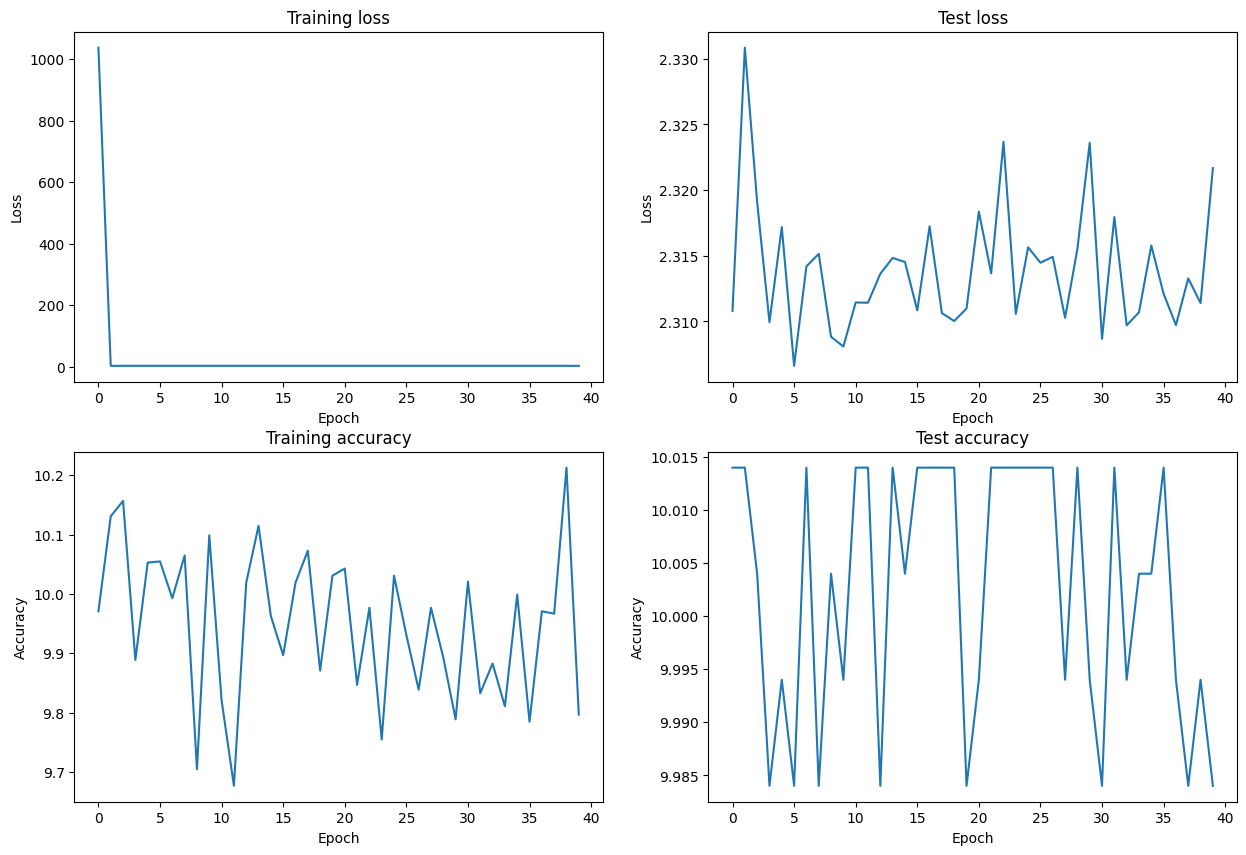

In [9]:
fig, ax = plt.subplots(2, 2, figsize=(15,10))
ax = ax.flatten()  # Flatten the array of axes for easier indexing

ax[0].plot(adam_poly.loss_train, label="train loss")
ax[1].plot(adam_poly.loss_test, label="val loss")
ax[2].plot(adam_poly.acc_train, label="train accuracy")
ax[3].plot(adam_poly.acc_test, label="val accuracy")

ax[0].set_title("Training loss")
ax[1].set_title("Test loss")
ax[2].set_title("Training accuracy")
ax[3].set_title("Test accuracy")

ax[0].set_xlabel("Epoch")
ax[1].set_xlabel("Epoch")
ax[2].set_xlabel("Epoch")
ax[3].set_xlabel("Epoch")

ax[0].set_ylabel("Loss")
ax[1].set_ylabel("Loss")
ax[2].set_ylabel("Accuracy")
ax[3].set_ylabel("Accuracy")

plt.show()

cosine schedular

In [14]:
import torch.optim.lr_scheduler

def main_with_schd_2(batch_size=128, lr=0.1, epochs=5, cuda=False, transform="normalize"):
    p = False
    model = ConvNet()
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr)

    if cuda:  # only with GPU, and not with CPU
        cudnn.benchmark = True
        model = model.cuda()
        criterion = criterion.cuda()

    # Get the data
    train, test = get_dataset(batch_size, cuda, transform)

    # init plots
    plot = AccLossPlot()
    global loss_plot
    loss_plot = TrainLossPlot()

    # scheduler: Cosine Annealing
    lr_sched = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    # We iterate on the epochs 
    for i in range(epochs):
        print("Epoch " + str(i + 1))
        # Train phase
        top1_acc, avg_top5_acc, loss = epoch(train, model, criterion, optimizer, cuda)
        # Test phase
        top1_acc_test, top5_acc_test, loss_test = epoch(test, model, criterion, cuda=cuda)

        # step the scheduler after one epoch
        lr_sched.step()

        # plot
        plot.update(loss.avg, loss_test.avg, top1_acc.avg, top1_acc_test.avg, plot=p)

    return plot


In [15]:
cosine_sch_plot = main_with_schd_2(32, 0.1, epochs=100, cuda=True, transform="normalize")

Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15
Epoch 16
Epoch 17
Epoch 18
Epoch 19
Epoch 20
Epoch 21
Epoch 22
Epoch 23
Epoch 24
Epoch 25
Epoch 26
Epoch 27
Epoch 28
Epoch 29
Epoch 30
Epoch 31
Epoch 32
Epoch 33
Epoch 34
Epoch 35
Epoch 36
Epoch 37
Epoch 38
Epoch 39
Epoch 40
Epoch 41
Epoch 42
Epoch 43
Epoch 44
Epoch 45
Epoch 46
Epoch 47
Epoch 48
Epoch 49
Epoch 50
Epoch 51
Epoch 52
Epoch 53
Epoch 54
Epoch 55
Epoch 56
Epoch 57
Epoch 58
Epoch 59
Epoch 60
Epoch 61
Epoch 62
Epoch 63
Epoch 64
Epoch 65
Epoch 66
Epoch 67
Epoch 68
Epoch 69
Epoch 70
Epoch 71
Epoch 72
Epoch 73
Epoch 74
Epoch 75
Epoch 76
Epoch 77
Epoch 78
Epoch 79
Epoch 80
Epoch 81
Epoch 82
Epoch 83
Epoch 84
Epoch 85
Epoch 86
Epoch 87
Epoch 88
Epoch 89
Epoch 90
Epoch 91
Epoch 92
Epoch 93
Epoch 94
Epoch 95
Epoch 96
Epoch 97
Epoch 98
Epoch 99
Epoch 100


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

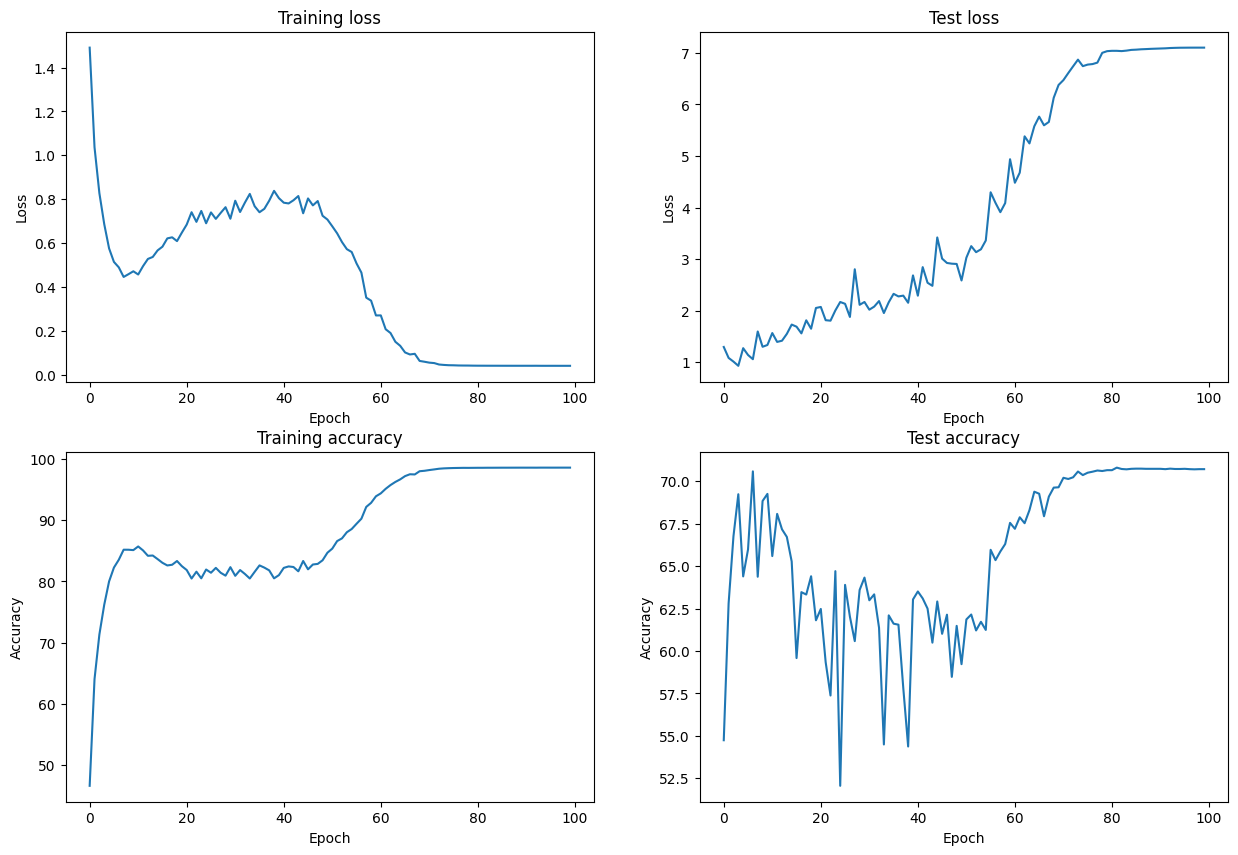

In [16]:
fig, ax = plt.subplots(2, 2, figsize=(15,10))
ax = ax.flatten()  # Flatten the array of axes for easier indexing

ax[0].plot(cosine_sch_plot.loss_train, label="train loss")
ax[1].plot(cosine_sch_plot.loss_test, label="val loss")
ax[2].plot(cosine_sch_plot.acc_train, label="train accuracy")
ax[3].plot(cosine_sch_plot.acc_test, label="val accuracy")

ax[0].set_title("Training loss")
ax[1].set_title("Test loss")
ax[2].set_title("Training accuracy")
ax[3].set_title("Test accuracy")

ax[0].set_xlabel("Epoch")
ax[1].set_xlabel("Epoch")
ax[2].set_xlabel("Epoch")
ax[3].set_xlabel("Epoch")

ax[0].set_ylabel("Loss")
ax[1].set_ylabel("Loss")
ax[2].set_ylabel("Accuracy")
ax[3].set_ylabel("Accuracy")

plt.show()

## 3.4 Regularization of the network by dropout

In [21]:
class ConvNet(nn.Module):
    """
    This class defines the structure of the neural network
    """

    def __init__(self, dropout_rate=0.5):
        super(ConvNet, self).__init__()
        # We first define the convolution and pooling layers as a features extractor
        self.features = nn.Sequential(
            nn.Conv2d(3,32,(5,5),stride=1,padding=2),
            nn.ReLU(),
            nn.MaxPool2d((2,2),stride=2,padding=0),

            nn.Conv2d(32,64,(5,5),stride=1,padding=2),
            nn.ReLU(),
            nn.MaxPool2d((2,2),stride=2,padding=0),

            nn.Conv2d(64,64,(5,5),stride=1,padding=2),
            nn.ReLU(),
            nn.MaxPool2d((2,2),stride=2,padding=0)
        )
        # We then define fully connected layers as a classifier
        self.classifier = nn.Sequential(
            nn.Linear(1024, 1000),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(1000, 10),
            # Reminder: The softmax is included in the loss, do not put it here
        )

    # Method called when we apply the network to an input batch
    def forward(self, input):
        bsize = input.size(0) # batch size
        output = self.features(input) # output of the conv layers
        output = output.view(bsize, -1) # we flatten the 2D feature maps into one 1D vector for each input
        output = self.classifier(output) # we compute the output of the fc layers
        return output

In [28]:
droup_out_plot = main_with_schd(32, 0.01,epochs=100,cuda=True,transform = "normalize")

Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15
Epoch 16
Epoch 17
Epoch 18
Epoch 19
Epoch 20
Epoch 21
Epoch 22
Epoch 23
Epoch 24
Epoch 25
Epoch 26
Epoch 27
Epoch 28
Epoch 29
Epoch 30
Epoch 31
Epoch 32
Epoch 33
Epoch 34
Epoch 35
Epoch 36
Epoch 37
Epoch 38
Epoch 39
Epoch 40
Epoch 41
Epoch 42
Epoch 43
Epoch 44
Epoch 45
Epoch 46
Epoch 47
Epoch 48
Epoch 49
Epoch 50
Epoch 51
Epoch 52
Epoch 53
Epoch 54
Epoch 55
Epoch 56
Epoch 57
Epoch 58
Epoch 59
Epoch 60
Epoch 61
Epoch 62
Epoch 63
Epoch 64
Epoch 65
Epoch 66
Epoch 67
Epoch 68
Epoch 69
Epoch 70
Epoch 71
Epoch 72
Epoch 73
Epoch 74
Epoch 75
Epoch 76
Epoch 77
Epoch 78
Epoch 79
Epoch 80
Epoch 81
Epoch 82
Epoch 83
Epoch 84
Epoch 85
Epoch 86
Epoch 87
Epoch 88
Epoch 89
Epoch 90
Epoch 91
Epoch 92
Epoch 93
Epoch 94
Epoch 95
Epoch 96
Epoch 97
Epoch 98
Epoch 99
Epoch 100


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

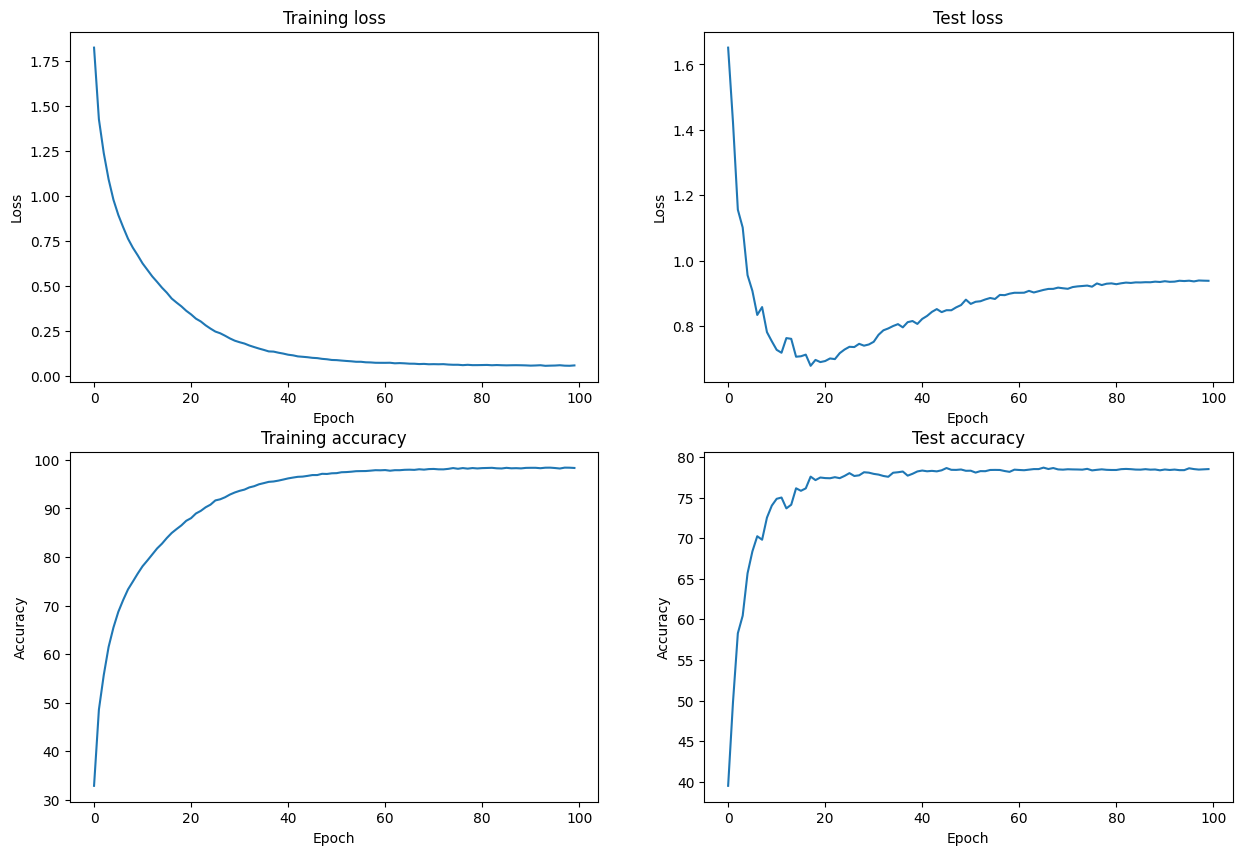

In [29]:
fig, ax = plt.subplots(2, 2, figsize=(15,10))
ax = ax.flatten()  # Flatten the array of axes for easier indexing

ax[0].plot(droup_out_plot.loss_train, label="train loss")
ax[1].plot(droup_out_plot.loss_test, label="val loss")
ax[2].plot(droup_out_plot.acc_train, label="train accuracy")
ax[3].plot(droup_out_plot.acc_test, label="val accuracy")

ax[0].set_title("Training loss")
ax[1].set_title("Test loss")
ax[2].set_title("Training accuracy")
ax[3].set_title("Test accuracy")

ax[0].set_xlabel("Epoch")
ax[1].set_xlabel("Epoch")
ax[2].set_xlabel("Epoch")
ax[3].set_xlabel("Epoch")

ax[0].set_ylabel("Loss")
ax[1].set_ylabel("Loss")
ax[2].set_ylabel("Accuracy")
ax[3].set_ylabel("Accuracy")

plt.show()

Influence of the hyperparameter

In [30]:
hyper_param_plot = {}

for hyper_param in [0.1,0.2,0.3,0.4,0.5]:
    print("Hyper parameter = ", hyper_param)
    hyper_param_plot[hyper_param] = main(32, 0.1,epochs=50,cuda=True)
    print("#"*50)

Hyper parameter =  0.1
Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15
Epoch 16
Epoch 17
Epoch 18
Epoch 19
Epoch 20
Epoch 21
Epoch 22
Epoch 23
Epoch 24
Epoch 25
Epoch 26
Epoch 27
Epoch 28
Epoch 29
Epoch 30
Epoch 31
Epoch 32
Epoch 33
Epoch 34
Epoch 35
Epoch 36
Epoch 37
Epoch 38
Epoch 39
Epoch 40
Epoch 41
Epoch 42
Epoch 43
Epoch 44
Epoch 45
Epoch 46
Epoch 47
Epoch 48
Epoch 49
Epoch 50
##################################################
Hyper parameter =  0.2
Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15
Epoch 16
Epoch 17
Epoch 18
Epoch 19
Epoch 20
Epoch 21
Epoch 22
Epoch 23
Epoch 24
Epoch 25
Epoch 26
Epoch 27
Epoch 28
Epoch 29
Epoch 30
Epoch 31
Epoch 32
Epoch 33
Epoch 34
Epoch 35
Epoch 36
Epoch 37
Epoch 38
Epoch 39
Epoch 40
Epoch 41
Epoch 42
Epoch 43
Epoch 44
Epoch 45
Epoch 46
Epoch 47
Epoch 48
Epoch 49
Epoch 50
#####################

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

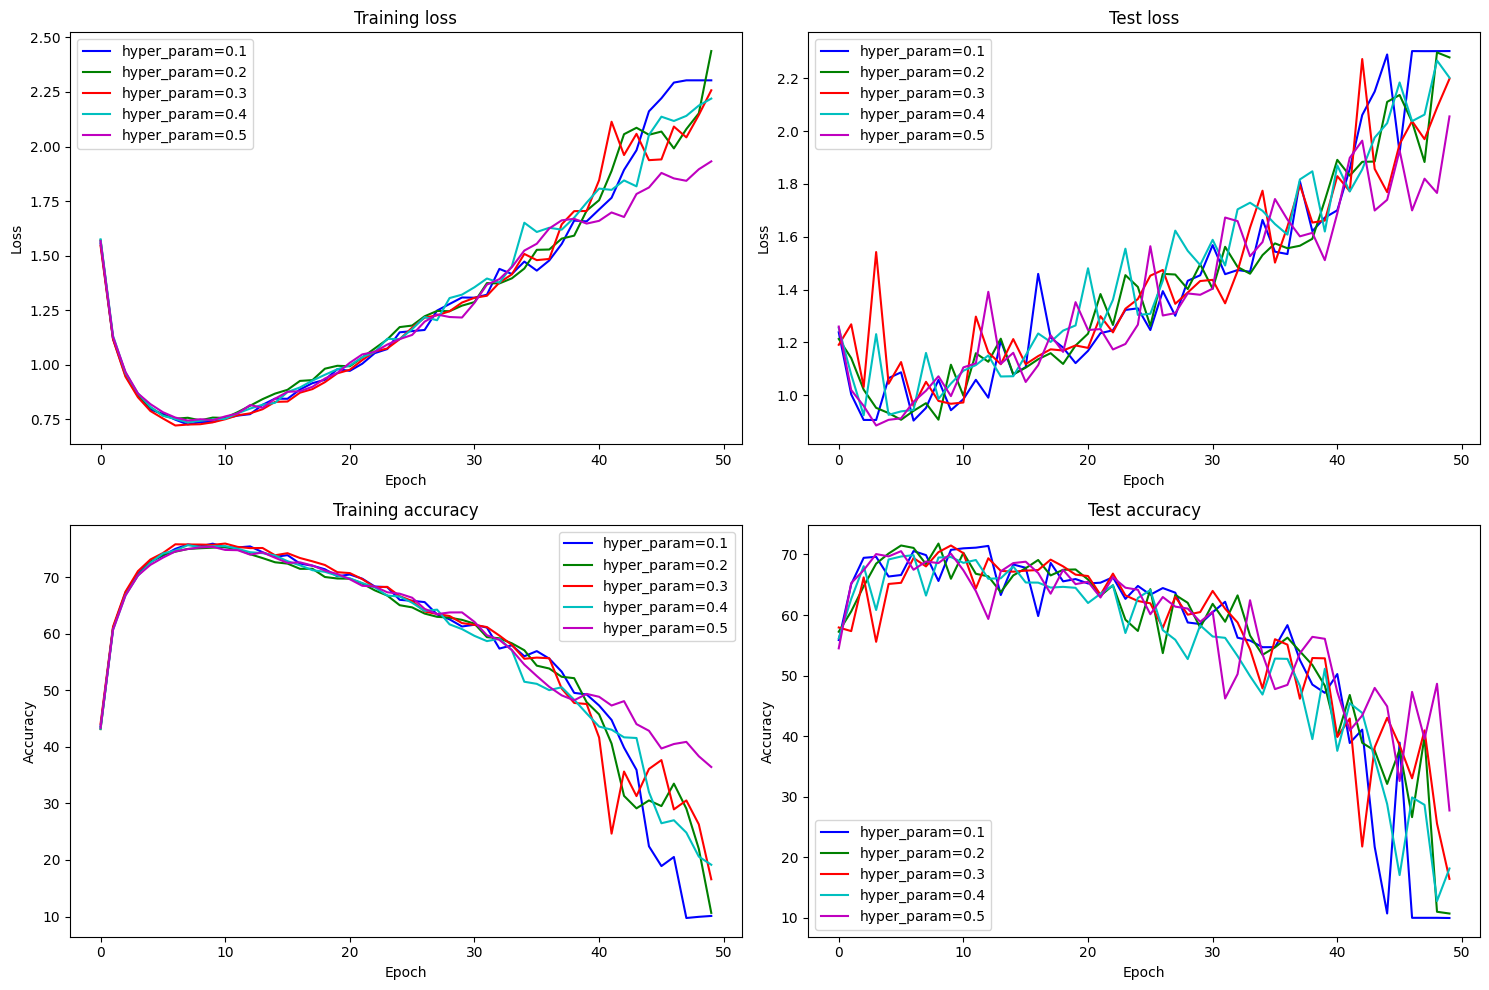

In [31]:
fig, ax = plt.subplots(2, 2, figsize=(15, 10))
ax = ax.flatten()

hyper_params_list =  [0.1,0.2,0.3,0.4,0.5]
colors = ['b', 'g', 'r', 'c', 'm','y']  # Define a list of colors

for i, hyper_param in enumerate(hyper_params_list):
    ax[0].plot(hyper_param_plot[hyper_param].loss_train, color=colors[i], label=f"hyper_param={hyper_param}")
    ax[1].plot(hyper_param_plot[hyper_param].loss_test, color=colors[i], label=f"hyper_param={hyper_param}")
    ax[2].plot(hyper_param_plot[hyper_param].acc_train, color=colors[i], label=f"hyper_param={hyper_param}")
    ax[3].plot(hyper_param_plot[hyper_param].acc_test, color=colors[i], label=f"hyper_param={hyper_param}")

# Set titles
ax[0].set_title("Training loss")
ax[1].set_title("Test loss")
ax[2].set_title("Training accuracy")
ax[3].set_title("Test accuracy")

# Set labels
for i in range(4):
    ax[i].set_xlabel("Epoch")
    if i < 2:  # For the first row (loss)
        ax[i].set_ylabel("Loss")
    else:  # For the second row (accuracy)
        ax[i].set_ylabel("Accuracy")

# Add a legend
for i in range(4):
    ax[i].legend()

plt.tight_layout()
plt.show()

## 3.5 Use of batch normalization

In [32]:
class ConvNet(nn.Module):

    def __init__(self, dropout_rate=0.5):
        super(ConvNet, self).__init__()
        # We first define the convolution and pooling layers as a features extractor
        self.features = nn.Sequential(
            nn.Conv2d(3,32,(5,5),stride=1,padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((2,2),stride=2,padding=0),

            nn.Conv2d(32,64,(5,5),stride=1,padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d((2,2),stride=2,padding=0),

            nn.Conv2d(64,64,(5,5),stride=1,padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d((2,2),stride=2,padding=0)
        )
        # We then define fully connected layers as a classifier
        self.classifier = nn.Sequential(
            nn.Linear(1024, 1000),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(1000, 10),
            # Reminder: The softmax is included in the loss, do not put it here
        )

    # Method called when we apply the network to an input batch
    def forward(self, input):
        bsize = input.size(0) # batch size
        output = self.features(input) # output of the conv layers
        output = output.view(bsize, -1) # we flatten the 2D feature maps into one 1D vector for each input
        output = self.classifier(output) # we compute the output of the fc layers
        return output

In [33]:
batch_norm_plot = main_with_schd(32, 0.01,epochs=100,cuda=True,transform = "normalize")

Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15
Epoch 16
Epoch 17
Epoch 18
Epoch 19
Epoch 20
Epoch 21
Epoch 22
Epoch 23
Epoch 24
Epoch 25
Epoch 26
Epoch 27
Epoch 28
Epoch 29
Epoch 30
Epoch 31
Epoch 32
Epoch 33
Epoch 34
Epoch 35
Epoch 36
Epoch 37
Epoch 38
Epoch 39
Epoch 40
Epoch 41
Epoch 42
Epoch 43
Epoch 44
Epoch 45
Epoch 46
Epoch 47
Epoch 48
Epoch 49
Epoch 50
Epoch 51
Epoch 52
Epoch 53
Epoch 54
Epoch 55
Epoch 56
Epoch 57
Epoch 58
Epoch 59
Epoch 60
Epoch 61
Epoch 62
Epoch 63
Epoch 64
Epoch 65
Epoch 66
Epoch 67
Epoch 68
Epoch 69
Epoch 70
Epoch 71
Epoch 72
Epoch 73
Epoch 74
Epoch 75
Epoch 76
Epoch 77
Epoch 78
Epoch 79
Epoch 80
Epoch 81
Epoch 82
Epoch 83
Epoch 84
Epoch 85
Epoch 86
Epoch 87
Epoch 88
Epoch 89
Epoch 90
Epoch 91
Epoch 92
Epoch 93
Epoch 94
Epoch 95
Epoch 96
Epoch 97
Epoch 98
Epoch 99
Epoch 100


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

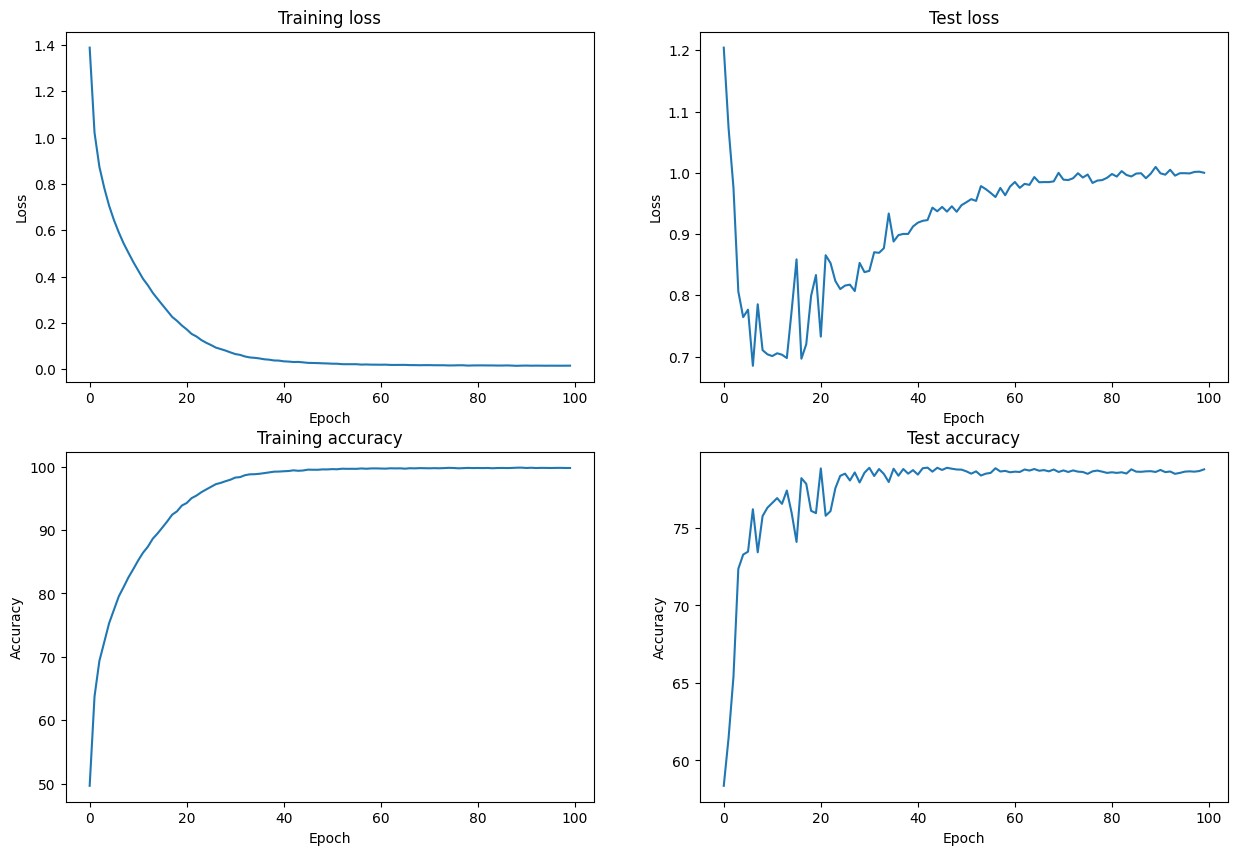

In [34]:
fig, ax = plt.subplots(2, 2, figsize=(15,10))
ax = ax.flatten()  # Flatten the array of axes for easier indexing

ax[0].plot(batch_norm_plot.loss_train, label="train loss")
ax[1].plot(batch_norm_plot.loss_test, label="val loss")
ax[2].plot(batch_norm_plot.acc_train, label="train accuracy")
ax[3].plot(batch_norm_plot.acc_test, label="val accuracy")

ax[0].set_title("Training loss")
ax[1].set_title("Test loss")
ax[2].set_title("Training accuracy")
ax[3].set_title("Test accuracy")

ax[0].set_xlabel("Epoch")
ax[1].set_xlabel("Epoch")
ax[2].set_xlabel("Epoch")
ax[3].set_xlabel("Epoch")

ax[0].set_ylabel("Loss")
ax[1].set_ylabel("Loss")
ax[2].set_ylabel("Accuracy")
ax[3].set_ylabel("Accuracy")

plt.show()

batch norm without dropout:

In [35]:
class ConvNet(nn.Module):

    def __init__(self, dropout_rate=0.5):
        super(ConvNet, self).__init__()
        # We first define the convolution and pooling layers as a features extractor
        self.features = nn.Sequential(
            nn.Conv2d(3,32,(5,5),stride=1,padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((2,2),stride=2,padding=0),

            nn.Conv2d(32,64,(5,5),stride=1,padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d((2,2),stride=2,padding=0),

            nn.Conv2d(64,64,(5,5),stride=1,padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d((2,2),stride=2,padding=0)
        )
        # We then define fully connected layers as a classifier
        self.classifier = nn.Sequential(
            nn.Linear(1024, 1000),
            nn.ReLU(),
            # nn.Dropout(dropout_rate),
            nn.Linear(1000, 10),
            # Reminder: The softmax is included in the loss, do not put it here
        )

    # Method called when we apply the network to an input batch
    def forward(self, input):
        bsize = input.size(0) # batch size
        output = self.features(input) # output of the conv layers
        output = output.view(bsize, -1) # we flatten the 2D feature maps into one 1D vector for each input
        output = self.classifier(output) # we compute the output of the fc layers
        return output

In [36]:
batch_norm_wo_drop_plot = main_with_schd(32, 0.01,epochs=100,cuda=True,transform = "normalize")

Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15
Epoch 16
Epoch 17
Epoch 18
Epoch 19
Epoch 20
Epoch 21
Epoch 22
Epoch 23
Epoch 24
Epoch 25
Epoch 26
Epoch 27
Epoch 28
Epoch 29
Epoch 30
Epoch 31
Epoch 32
Epoch 33
Epoch 34
Epoch 35
Epoch 36
Epoch 37
Epoch 38
Epoch 39
Epoch 40
Epoch 41
Epoch 42
Epoch 43
Epoch 44
Epoch 45
Epoch 46
Epoch 47
Epoch 48
Epoch 49
Epoch 50
Epoch 51
Epoch 52
Epoch 53
Epoch 54
Epoch 55
Epoch 56
Epoch 57
Epoch 58
Epoch 59
Epoch 60
Epoch 61
Epoch 62
Epoch 63
Epoch 64
Epoch 65
Epoch 66
Epoch 67
Epoch 68
Epoch 69
Epoch 70
Epoch 71
Epoch 72
Epoch 73
Epoch 74
Epoch 75
Epoch 76
Epoch 77
Epoch 78
Epoch 79
Epoch 80
Epoch 81
Epoch 82
Epoch 83
Epoch 84
Epoch 85
Epoch 86
Epoch 87
Epoch 88
Epoch 89
Epoch 90
Epoch 91
Epoch 92
Epoch 93
Epoch 94
Epoch 95
Epoch 96
Epoch 97
Epoch 98
Epoch 99
Epoch 100


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

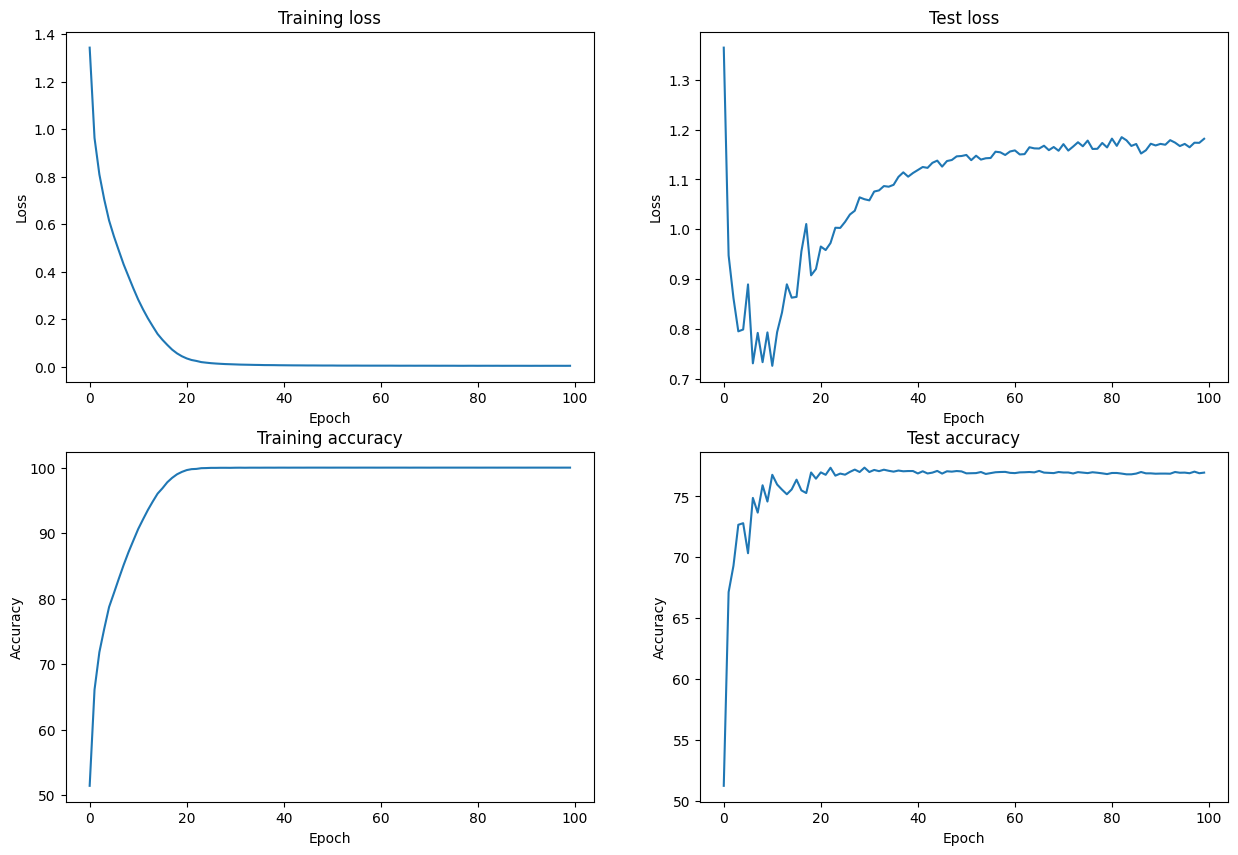

In [37]:
fig, ax = plt.subplots(2, 2, figsize=(15,10))
ax = ax.flatten()  # Flatten the array of axes for easier indexing

ax[0].plot(batch_norm_wo_drop_plot.loss_train, label="train loss")
ax[1].plot(batch_norm_wo_drop_plot.loss_test, label="val loss")
ax[2].plot(batch_norm_wo_drop_plot.acc_train, label="train accuracy")
ax[3].plot(batch_norm_wo_drop_plot.acc_test, label="val accuracy")

ax[0].set_title("Training loss")
ax[1].set_title("Test loss")
ax[2].set_title("Training accuracy")
ax[3].set_title("Test accuracy")

ax[0].set_xlabel("Epoch")
ax[1].set_xlabel("Epoch")
ax[2].set_xlabel("Epoch")
ax[3].set_xlabel("Epoch")

ax[0].set_ylabel("Loss")
ax[1].set_ylabel("Loss")
ax[2].set_ylabel("Accuracy")
ax[3].set_ylabel("Accuracy")

plt.show()